# Overtake.GP · Anàlisi de dades

---

## Estructura del notebook

| Bloc | Contingut |
|------|-----------|
| **0. Configuració** | Imports, constants i càrrega de dades |
| **1. KPIs i SMART** | Verificació d'objectius i anàlisi descriptiu |
| **2. Tests estadístics** | Impacte d'esdeveniments clau (Mann-Whitney) |
| **3. Anàlisi de continguts** | Format, dia, hora, scatterplot, pairplot |
| **3.5 NER** | Entitats als captions, núvol de paraules, rànquing de pilots |
| **3.6 CLIP** | Classificació visual de posts |
| **4. Benchmarking** | Comparativa de creixement amb comptes referents |
| **5. Model predictiu** | Holt-Winters · projecció 6 mesos |
| **6. Conclusions** | Síntesi global · pendent de dades finals |
| **Annex A** | API Metricool · infraestructura i demografia |
| **Annex B** | MySQL · procés explorat i descartat |


---
# Bloc 0 · Configuració i càrrega de dades

Centralitzem aquí tots els imports, constants i càrregues de dades.

*Tots els imports del projecte es troben en aquesta cel·la per facilitar la detecció d'errors de dependències en iniciar el notebook.*


In [100]:
# ── Imports ────────────────────────────────────────────
import pandas as pd
import numpy as np
from scipy import stats
from sqlalchemy import create_engine
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from scipy.stats import spearmanr
from datetime import datetime, timezone
import json

# ── NLP / Vision (Bloc 3.5 i 3.6) ──────────────────────────────────────────
from transformers import pipeline, CLIPProcessor, CLIPModel
from PIL import Image
import requests
from io import BytesIO
import torch
from tqdm import tqdm
tqdm.pandas()
from wordcloud import WordCloud

print('Llibreries carregades correctament')


Llibreries carregades correctament


In [ ]:
# ── Constants ───────────────────────────────────────────

# Paths dels fitxers de dades
DATA_DIR = ''   # canvia si els CSV estan en una subcarpeta

FITXERS_COMPTES = {
    'overtake'            : 'overtake.gp-historical-stats.csv',
    'everithingmotoracing': 'everythingmotoracing-historical-stats.csv',
    'motociclismo_es'     : 'motociclismo_es-historical-stats.csv',
    'moto_gp'             : 'motogp-historical-stats.csv',
    'motorsportcom'       : 'motorsportcom-historical-stats.csv',
    'motorspain_77'       : 'motospain77-historical-stats.csv',
    'brake_gp'            : 'brake.gp-historical-stats.csv',
}

FITXER_POSTS = 'instagram-posts_2025-05-23_2026-05-23.csv'

# Dates clau del projecte
DATA_INICI_TFG    = '2025-09-01'   # inici periode academic
DATA_INICI_LLARG  = '2024-01-01'   # inici periode llarg benchmarking
DATA_INICI_CURT   = '2024-11-12'   # inici periode curt (brake_gp disponible)

# Nota: credencials MySQL eliminades — vegeu Annex B
print('Constants definides correctament')


## Càrrega de dades

Carreguem tots els datasets en aquesta secció. La funció `import_csv_comptes` 
unifica els fitxers dels comptes referents en un sol DataFrame, afegint la columna `account`.


In [3]:
# ── Funció de càrrega ────────────────────────────────────
def import_csv_comptes(diccionari):
    """
    Importa múltiples CSVs amb el mateix format, afegeix la columna 'account'
    i els concatena en un únic DataFrame.

    Paràmetres:
        diccionari (dict): {nom_compte: fitxer_csv}
    Retorna:
        pd.DataFrame: DataFrame unificat amb columna 'account'
    """
    llista = []
    for nom, fitxer in diccionari.items():
        temp = pd.read_csv(DATA_DIR + fitxer)
        temp.columns = temp.columns.str.strip().str.lstrip('\ufeff')
        temp['account'] = nom
        llista.append(temp)
        print(f'  {nom}: {len(temp)} files')
    return pd.concat(llista, ignore_index=True)


# ── Dataset 1: comptes comparatius (InstaTrack) ───────────
print('Carregant comptes...')
df_comptes = import_csv_comptes(FITXERS_COMPTES)

# ── Dataset 2: posts Overtake.GP (Metricool) ──────────────
print('\nCarregant posts...')
posts = pd.read_csv(DATA_DIR + FITXER_POSTS,
                    sep=';', quotechar='"',
                    on_bad_lines='skip', encoding='utf-8')
posts.columns = posts.columns.str.strip().str.lstrip('\ufeff')
print(f'  posts: {len(posts)} files')

# ── Dataset 3: sèrie temporal Overtake.GP ────────────────
hist = df_comptes[df_comptes['account'] == 'overtake'].copy()

print(f'\nTotal files df_comptes : {len(df_comptes)}')
print(f'Total posts            : {len(posts)}')
print(f'Total dies hist        : {len(hist)}')


Carregant comptes...
  overtake: 878 files
  everithingmotoracing: 2013 files
  motociclismo_es: 1055 files
  moto_gp: 2775 files
  motorsportcom: 2265 files
  motorspain_77: 1888 files
  brake_gp: 562 files

Carregant posts...
  posts: 394 files

Total files df_comptes : 11436
Total posts            : 394
Total dies hist        : 878


In [4]:
# ── Neteja unificada ─────────────────────────────────────

# Conversions de tipus
df_comptes['date'] = pd.to_datetime(df_comptes['date'])
df_comptes['engagement_rate'] = (
    df_comptes['engagement_rate'].str.replace('%','').astype(float)
)
df_comptes['comments_to_likes_ratio'] = (
    df_comptes['comments_to_likes_ratio'].str.replace('%','').astype(float)
)
df_comptes = df_comptes.sort_values(['account','date']).reset_index(drop=True)

# Columnes derivades
df_comptes['daily_gain']    = df_comptes.groupby('account')['followers_count'].diff()
df_comptes['posts_per_day'] = df_comptes['weekly_posts'] / 7
df_comptes['month']         = df_comptes['date'].dt.to_period('M')
df_comptes['growth_rate']   = (
    df_comptes['daily_gain'] /
    df_comptes['followers_count'].replace(0, np.nan) * 100
)

# Posts: conversions de tipus
posts['Timestamp'] = pd.to_datetime(posts['Timestamp'])
for col in ['Engagement','Likes','Views','Reach (Organic)',
            'Saved','Comments','Shares','Interactions']:
    posts[col] = pd.to_numeric(
        posts[col].astype(str).str.replace(',','.'), errors='coerce'
    )
posts['hour']     = posts['Timestamp'].dt.hour
posts['weekday']  = posts['Timestamp'].dt.day_name()
posts['month']    = posts['Timestamp'].dt.to_period('M')
posts['hour_bin'] = pd.cut(posts['hour'],
                            bins=[0,6,10,13,17,21,24],
                            labels=['0-6h','7-10h','11-13h','14-17h','18-21h','22-24h'])

# Sèrie temporal Overtake (actualitzada amb columnes derivades)
hist = df_comptes[df_comptes['account'] == 'overtake'].copy().reset_index(drop=True)

# Subconjunts per benchmarking
df_llarg = df_comptes[
    (df_comptes['date'] >= DATA_INICI_LLARG) &
    (df_comptes['account'] != 'brake_gp')
].copy()
df_llarg['index_100'] = df_llarg.groupby('account')['followers_count'].transform(
    lambda x: x / x.iloc[0] * 100
)

df_curt = df_comptes[df_comptes['date'] >= DATA_INICI_CURT].copy()
df_curt['index_100'] = df_curt.groupby('account')['followers_count'].transform(
    lambda x: x / x.iloc[0] * 100
)

print('Neteja i transformacions completades')
print(f'  df_comptes : {len(df_comptes):,} files')
print(f'  df_llarg   : {len(df_llarg):,} files · {df_llarg["account"].nunique()} comptes')
print(f'  df_curt    : {len(df_curt):,} files · {df_curt["account"].nunique()} comptes')
print(f'  hist       : {len(hist):,} files')
print(f'  posts      : {len(posts):,} posts')


Neteja i transformacions completades
  df_comptes : 11,436 files
  df_llarg   : 5,265 files · 6 comptes
  df_curt    : 3,931 files · 7 comptes
  hist       : 878 files
  posts      : 394 posts


---
# Bloc 1 · Anàlisi descriptiu i KPIs

## Fonts de dades

Per a aquesta anàlisi fem servir dos datasets complementaris:

- **InstaTrack** · seguiment diari del compte des del 31 de desembre de 2023 fins a l'actualitat. Inclou 7 comptes del sector del motociclisme amb un total de ~11.000 registres. S'utilitza per als KPIs basats en evolució temporal de seguidors i freqüència de publicació.

- **Metricool** · registre individual de publicacions des de maig de 2025 fins a l'actualitat, amb informació de més de 380 posts. S'utilitza per al KPI d'engagement, que requereix dades a nivell de post individual.

## Objectius SMART verificats

| # | Objectiu | Mètrica | Font | Llindar |
|---|----------|---------|------|---------|
| SMART 1 | Creixement de seguidors set-25 → jun-26 | % increment followers | InstaTrack | ≥ 25% |
| SMART 2 | Seguidors per publicació | daily_gain / posts_per_day | InstaTrack | ≥ 15 seg/post |
| SMART 3 | Freqüència de publicació | posts_per_day | InstaTrack | ≥ 1 post/dia |
| SMART 4 | Taxa d'engagement per post | Engagement (%) | Metricool | > 5% |


In [6]:
# ── Verificació objectius SMART ──────────────────────────

# SMART 1: creixement set-25 → avui
seg_set25  = hist[hist['date'] >= DATA_INICI_TFG]['followers_count'].iloc[0]
seg_avui   = hist['followers_count'].iloc[-1]
smart1     = (seg_avui / seg_set25 - 1) * 100

# SMART 2: seguidors per publicació (aproximació)
# Nota metodològica: cap eina registra conversió directa a seguidors per post.
# S'aproxima dividint el guany total de seguidors pel nombre de publicacions.
periode    = hist[hist['date'] >= DATA_INICI_TFG].copy()
guany_total = periode['followers_count'].iloc[-1] - periode['followers_count'].iloc[0]
total_posts = periode['posts_per_day'].sum()
smart2      = guany_total / total_posts

# SMART 3: posts per dia
smart3 = hist[hist['date'] >= DATA_INICI_TFG]['posts_per_day'].mean()

# SMART 4: engagement mitjà per post
smart4 = posts['Engagement'].mean()

# Taula de resultats
print('=' * 55)
print(f'{"KPI":<12} {"Valor real":>12} {"Objectiu":>12} {"Resultat":>10}')
print('=' * 55)
print(f'{"SMART 1":<12} {smart1:>11.1f}% {"≥ 25%":>12} {"✅" if smart1>=25 else "❌":>10}')
print(f'{"SMART 2":<12} {smart2:>11.1f}  {"≥ 15 seg":>12} {"✅" if smart2>=15 else "❌":>10}')
print(f'{"SMART 3":<12} {smart3:>11.2f}  {"≥ 1.0":>12} {"✅" if smart3>=1 else "❌":>10}')
print(f'{"SMART 4":<12} {smart4:>11.1f}% {"> 5%":>12} {"✅" if smart4>5 else "❌":>10}')
print('=' * 55)


KPI            Valor real     Objectiu   Resultat
SMART 1             38.0%        ≥ 25%          ✅
SMART 2             20.7      ≥ 15 seg          ✅
SMART 3             1.34         ≥ 1.0          ✅
SMART 4             10.2%         > 5%          ✅


## Resultats · Objectius SMART

Tots quatre objectius SMART s'han assolit durant el període setembre 2025 – juny 2026:

- **SMART 1 · Creixement:** s'ha assolit un increment del 38.0%, superant en 9.9 punts percentuals l'objectiu del 25%.

- **SMART 2 · Seguidors per publicació:** s'ha obtingut una mitjana de 20.7 seguidors nous per publicació, un 40% per sobre de l'objectiu de 15.  
  *Nota metodològica: valor aproximat. Cap eina registra la conversió directa a seguidors per post individual.*

- **SMART 3 · Freqüència:** s'ha mantingut una mitjana d'1.34 posts per dia, superant l'objectiu mínim d'1 publicació diària.

- **SMART 4 · Engagement:** s'ha obtingut una taxa mitjana del 10.2%, més del doble de l'objectiu del 5%.

Els resultats de SMART 2 i SMART 4 són especialment significatius perquè reflecteixen no només creixement en volum, sinó qualitat de la interacció amb l'audiència — un indicador clau de la sostenibilitat del projecte a llarg termini.


---
# Bloc 2 · Anàlisi d'impacte d'accions estratègiques

En aquest bloc volem demostrar si les accions dutes a terme durant el projecte han tingut un impacte estadísticament significatiu en el creixement diari de seguidors d'Overtake.GP.

Analitzem tres esdeveniments clau:
1. **Pic viral · juny 2024** → +711 seguidors en un dia
2. **Inici TFG · setembre 2025** → professionalització del compte
3. **GP Catalunya · maig 2026** → cobertura presencial acreditada

Per a cada esdeveniment comparem el creixement diari en una finestra de **30 dies abans i 30 dies després**. S'han escollit 30 dies perquè és un període prou ampli per capturar l'efecte sostingut d'una acció, sense incorporar altres esdeveniments que podrien contaminar l'anàlisi.

**Hipòtesi nul·la (H₀):** l'esdeveniment no ha produït cap canvi significatiu en el creixement diari de seguidors.

**Test:** Mann-Whitney U. No assumeix distribució normal i compara medianes en lloc de mitjanes, més robust davant pics i outliers propis de les dades de xarxes socials. Considerem estadísticament significatiu un **p-valor < 0.05**.


In [7]:
# ── Definició d'esdeveniments i finestra temporal ────────
FINESTRA = 30  # dies

esdeveniments = [
    {'nom': 'Pic viral juny 2024',      'data': '2024-06-04'},
    {'nom': 'Inici TFG setembre 2025',  'data': '2025-09-01'},
    {'nom': 'GP Catalunya maig 2026',   'data': '2026-05-01'},
]

# Mostrem les finestres abans/després per a cada esdeveniment
for e in esdeveniments:
    d = pd.Timestamp(e['data'])
    abans   = hist[(hist['date'] >= d - pd.Timedelta(days=FINESTRA)) &
                   (hist['date'] <  d)]['daily_gain'].dropna()
    despres = hist[(hist['date'] >= d) &
                   (hist['date'] <  d + pd.Timedelta(days=FINESTRA))]['daily_gain'].dropna()
    print(f"\n{'='*45}")
    print(f"{e['nom']}")
    print(f"  Abans  → n={len(abans):2d} · mediana={abans.median():.1f} · std={abans.std():.1f}")
    print(f"  Després→ n={len(despres):2d} · mediana={despres.median():.1f} · std={despres.std():.1f}")



Pic viral juny 2024
  Abans  → n=30 · mediana=40.5 · std=38.5
  Després→ n=30 · mediana=50.0 · std=130.3

Inici TFG setembre 2025
  Abans  → n=30 · mediana=11.0 · std=27.1
  Després→ n=30 · mediana=14.5 · std=22.1

GP Catalunya maig 2026
  Abans  → n=30 · mediana=31.0 · std=29.5
  Després→ n=27 · mediana=31.0 · std=40.9


In [8]:
# ── Test Mann-Whitney U ───────────────────────────────────
resultats = []

for e in esdeveniments:
    d = pd.Timestamp(e['data'])
    abans   = hist[(hist['date'] >= d - pd.Timedelta(days=FINESTRA)) &
                   (hist['date'] <  d)]['daily_gain'].dropna()
    despres = hist[(hist['date'] >= d) &
                   (hist['date'] <  d + pd.Timedelta(days=FINESTRA))]['daily_gain'].dropna()

    stat, pval = stats.mannwhitneyu(abans, despres, alternative='two-sided')

    if   pval < 0.001: sig = '*** (p<0.001)'
    elif pval < 0.01:  sig = '**  (p<0.01)'
    elif pval < 0.05:  sig = '*   (p<0.05)'
    else:              sig = 'ns  (no significatiu)'

    resultats.append({
        'Esdeveniment'   : e['nom'],
        'Mediana abans'  : round(abans.median(), 1),
        'Mediana després': round(despres.median(), 1),
        'Diferència'     : round(despres.median() - abans.median(), 1),
        'p-valor'        : round(pval, 4),
        'Significació'   : sig,
    })

df_resultats = pd.DataFrame(resultats)
print(df_resultats.to_string(index=False))


           Esdeveniment  Mediana abans  Mediana després  Diferència  p-valor          Significació
    Pic viral juny 2024           40.5             50.0         9.5   0.4332 ns  (no significatiu)
Inici TFG setembre 2025           11.0             14.5         3.5   0.2834 ns  (no significatiu)
 GP Catalunya maig 2026           31.0             31.0         0.0   0.7431 ns  (no significatiu)


## Resultats · Test Mann-Whitney U

Cap dels tres esdeveniments analitzats supera el llindar de significació estadística (p < 0.05), de manera que no es pot rebutjar la hipòtesi nul·la amb les dades actuals.

Aquest resultat té dues explicacions complementàries:

**Alta variabilitat intrínseca:** el creixement diari d'Overtake.GP presenta desviacions estàndard molt elevades (fins a 130 seguidors/dia en el període post-viral), cosa que redueix la potència estadística del test i dificulta detectar diferències significatives entre períodes.

**Creixement sostingut vs. impacte puntual:** el patró de creixement d'Overtake.GP és consistent al llarg de tot el període, sense ruptures clares atribuïbles a esdeveniments concrets. Això suggereix que l'impacte de les accions és acumulatiu i estructural, no puntual.

El GP Catalunya acreditat (p=0.089) és el resultat més proper al llindar i el menys concloent amb les dades actuals, ja que la finestra de 30 dies post-esdeveniment no està completa. Els resultats definitius s'obtindran amb les dades actualitzades al 10 de juny.


---
# Bloc 3 · Anàlisi de continguts

1. Quin format funciona millor? → Imatge vs Carrusel
2. Quin dia de la setmana té més engagement?
3. Quina franja horària és millor per publicar?
4. Quins són els posts més exitosos i per què?
5. Hi ha correlació entre likes, shares i engagement?

In [9]:
# Quins formats tenim i quants posts de cada tipus?
print(posts['type'].value_counts())
print()

# Engagement mitjà per format
print(posts.groupby('type')['Engagement'].agg(['mean','median','count']).round(2))

type
FEED_IMAGE             321
FEED_CAROUSEL_ALBUM     73
Name: count, dtype: int64

                      mean  median  count
type                                     
FEED_CAROUSEL_ALBUM  11.18   10.26     73
FEED_IMAGE           10.00    9.66    321


In [10]:
# Mapejem els noms tècnics a etiquetes llegibles
posts['format'] = posts['type'].map({
    'FEED_IMAGE'          : 'Imatge',
    'FEED_CAROUSEL_ALBUM' : 'Carrusel'
})

# Verifiquem
print(posts['format'].value_counts())

format
Imatge      321
Carrusel     73
Name: count, dtype: int64


In [11]:
# ── Test Mann-Whitney: Imatge vs Carrusel ─────────────
img = posts[posts['format'] == 'Imatge']['Engagement'].dropna()
car = posts[posts['format'] == 'Carrusel']['Engagement'].dropna()

stat, pval = stats.mannwhitneyu(img, car, alternative='two-sided')

print(f"Imatge   → mediana: {img.median():.2f}% · n={len(img)}")
print(f"Carrusel → mediana: {car.median():.2f}% · n={len(car)}")
print(f"\np-valor: {pval:.4f}")
print(f"Significatiu (p<0.05): {'Sí ✅' if pval < 0.05 else 'No ❌'}")

Imatge   → mediana: 9.66% · n=321
Carrusel → mediana: 10.26% · n=73

p-valor: 0.0444
Significatiu (p<0.05): Sí ✅


## Format · Imatge vs Carrusel

El test Mann-Whitney U confirma que els carrusels obtenen un engagement 
significativament superior a les imatges (mediana 10.26% vs 9.66%, 
p = 0.044).

Cal interpretar aquest resultat amb cautela per dues raons:

- **Mostra reduïda:** els carrusels representen només 73 dels 394 posts 
  analitzats. Una mostra més gran permetria conclusions més robustes.
  
- **p-valor just al llindar:** amb p = 0.044, el resultat supera el 
  llindar de significació (p < 0.05) però per un marge estret. 
  Resultats propers al llindar s'interpreten com a tendència, 
  no com a evidència contundent.

Tot i això, la tendència és consistent i estadísticament significativa. 
Des d'un punt de vista editorial, les dades suggereixen que incrementar 
la proporció de carrusels podria millorar l'engagement global del compte.

In [12]:
# Engagement per dia de la setmana

ordre = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

etiquetes = ['Dilluns','Dimarts','Dimecres','Dijous','Divendres','Dissabte','Diumenge']

resum_dies = posts.groupby('weekday')['Engagement'].agg(

    ['median','mean','count']

).reindex(ordre).round(2)

resum_dies.index = etiquetes

print(resum_dies)

           median   mean  count
Dilluns      9.62  10.19     53
Dimarts      9.45  10.05     44
Dimecres    10.07  10.76     42
Dijous      10.26  10.56     45
Divendres    8.97   9.48     61
Dissabte     9.72   9.91     76
Diumenge    10.27  10.78     73


In [13]:
# ── Test Kruskal-Wallis: engagement per dia ───────────
grups = [
    posts[posts['weekday'] == dia]['Engagement'].dropna()
    for dia in ordre
]

stat, pval = stats.kruskal(*grups)

print(f"Kruskal-Wallis: stat={stat:.3f} · p-valor={pval:.4f}")
print(f"Significatiu (p<0.05): {'Sí ✅' if pval < 0.05 else 'No ❌'}")

Kruskal-Wallis: stat=6.235 · p-valor=0.3974
Significatiu (p<0.05): No ❌


## Dia de la setmana

Per comparar l'engagement entre més de dos grups, utilitzem el test 
Kruskal-Wallis, l'equivalent de Mann-Whitney per a múltiples categories.

**Hipòtesi nul·la:** l'engagement és igual independentment del dia 
de publicació.

El test retorna p = 0.397, molt per sobre del llindar de significació 
(p < 0.05). No es pot rebutjar la hipòtesi nul·la — les diferències 
observades entre dies no són estadísticament significatives.

Tot i això, les medianes mostren una tendència consistent amb el 
calendari esportiu del motociclisme:

- **Diumenge (10.27%)** i **Dijous (10.26%)** lideren l'engagement
- **Divendres (8.97%)** obté el resultat més baix
- Els pics coincideixen amb els dies de cursa (diumenge) i 
  d'inici d'entrenaments (dimecres-dijous)

Aquesta tendència no és estadísticament demostrable amb la mostra 
actual, però és coherent amb el comportament esperat de l'audiència. 
Amb una mostra més gran podria confirmar-se. Com a hipòtesi de treball, 
s'aconsella prioritzar les publicacions en aquests dies, sense 
desatendre la resta.

In [14]:
# Distribució de posts per franja horària
posts['hour_bin'] = pd.cut(
    posts['hour'],
    bins=[0, 6, 10, 13, 17, 21, 24],
    labels=['0-6h','7-10h','11-13h','14-17h','18-21h','22-24h']
)

resum_hores = posts.groupby('hour_bin', observed=True)['Engagement'].agg(
    ['median','mean','count']
).round(2)

print(resum_hores)

          median   mean  count
hour_bin                      
0-6h        9.28   9.28      2
7-10h      10.76  10.78     26
11-13h      9.97   9.95     59
14-17h      9.60  10.21    260
18-21h      9.91  10.18     40
22-24h     10.91  10.58      6


In [15]:
# ── Test Kruskal-Wallis: engagement per franja horària ──
franges = ['0-6h','7-10h','11-13h','14-17h','18-21h','22-24h']

grups_hores = [
    posts[posts['hour_bin'] == f]['Engagement'].dropna()
    for f in franges
]

stat, pval = stats.kruskal(*grups_hores)

print(f"Kruskal-Wallis: stat={stat:.3f} · p-valor={pval:.4f}")
print(f"Significatiu (p<0.05): {'Sí ✅' if pval < 0.05 else 'No ❌'}")

Kruskal-Wallis: stat=1.375 · p-valor=0.9271
Significatiu (p<0.05): No ❌


In [16]:
# ── Reagrupament en 3 franges ─────────────────────────
posts['hour_bin3'] = pd.cut(
    posts['hour'],
    bins=[0, 12, 18, 24],
    labels=['Matí (0-12h)', 'Tarda (12-18h)', 'Nit (18-24h)']
)

resum_3franges = posts.groupby('hour_bin3', observed=True)['Engagement'].agg(
    ['median', 'mean', 'count']
).round(2)

print(resum_3franges)

# Test Kruskal-Wallis amb les noves franges
grups3 = [
    posts[posts['hour_bin3'] == f]['Engagement'].dropna()
    for f in ['Matí (0-12h)', 'Tarda (12-18h)', 'Nit (18-24h)']
]

stat, pval = stats.kruskal(*grups3)
print(f"\nKruskal-Wallis: stat={stat:.3f} · p-valor={pval:.4f}")
print(f"Significatiu (p<0.05): {'Sí ✅' if pval < 0.05 else 'No ❌'}")

                median   mean  count
hour_bin3                           
Matí (0-12h)      9.79  10.04     59
Tarda (12-18h)    9.66  10.26    307
Nit (18-24h)      9.99  10.06     27

Kruskal-Wallis: stat=0.024 · p-valor=0.9879
Significatiu (p<0.05): No ❌


## Franja horària

S'han realitzat dos tests Kruskal-Wallis amb granularitats diferents:
- **6 franges** (p = 0.927) → no significatiu
- **3 franges** (p = 0.988) → no significatiu

En tots dos casos, la hipòtesi nul·la — que l'hora de publicació 
no té rellevància estadística sobre l'engagement — queda àmpliament 
respaldada.

**Limitació de la mostra:** el 78% dels posts s'han publicat en 
franja de tarda (12-18h), cosa que desvirtua la comparativa entre 
franges i redueix la potència estadística del test.

**Limitació geogràfica:** el compte té una audiència distribuïda 
globalment — Indonesia representa el 28% dels seguidors, seguida 
d'Espanya (10%), França (6%) i Itàlia (6%). Analitzar l'hora de 
publicació en hora local espanyola introdueix un biaix important, 
ja que no reflecteix l'hora de l'audiència real.

Una anàlisi més rigorosa requeriria convertir l'hora de publicació 
a UTC i creuar-la amb els fusos horaris dels seguidors per país, 
ponderant per volum d'audiència. Les dades actuals disponibles 
no permeten aquesta aproximació.

In [17]:
# Top 10 posts per engagement
top10_eng = posts.nlargest(10, 'Engagement')[
    ['Timestamp','format','Engagement','Likes','Views','Content']
].copy()
top10_eng['Content'] = top10_eng['Content'].str[:60]
top10_eng['Timestamp'] = top10_eng['Timestamp'].dt.strftime('%d/%m/%y')

print("=== TOP 10 · ENGAGEMENT ===")
print(top10_eng.to_string(index=False))

# Top 10 posts per views
top10_views = posts.nlargest(10, 'Views')[
    ['Timestamp','format','Views','Engagement','Content']
].copy()
top10_views['Content'] = top10_views['Content'].str[:60]
top10_views['Timestamp'] = top10_views['Timestamp'].dt.strftime('%d/%m/%y')

print("\n=== TOP 10 · VISUALITZACIONS ===")
print(top10_views.to_string(index=False))

=== TOP 10 · ENGAGEMENT ===
Timestamp   format  Engagement  Likes  Views                                                        Content
 17/01/26 Carrusel       27.13   6646  50450     Back to 2016 🔙😌\n\n#motogp #moto #motorsport #racing #2016
 24/11/25   Imatge       26.69  15389 142430 Max Verstappen has it clear. 🐜🦁\n \nAnd you? Which athlete do 
 10/12/25   Imatge       25.79   4651  43507   Fernando Alonso lauded Marc Márquez's spectacular return to 
 05/10/25   Imatge       25.05   4025  63912   Since Gresini became an independent team in 2022, five rider
 03/11/25 Carrusel       24.62  18759 500948 These motos are so... 😌\n\n#motogp #moto #motorsport #racing #
 28/11/25 Carrusel       21.98   2689  46804 A glimpse inside their minds 💭✨\n\n#motogp #moto #motorsport #
 09/03/26   Imatge       21.66   1798  15486   🏅 The Motul Grand Prix of the Netherlands has been named the
 01/03/26   Imatge       20.16   2859  24997   ❌ Things haven't started in the best way for Ducati, as toda


## Top posts

S'analitzen els 10 posts més exitosos en dues dimensions complementàries:

- **Top Engagement:** mesura la connexió emocional amb l'audiència — 
  la proporció d'usuaris que interactuen respecte als que veuen el post.
- **Top Visualitzacions:** mesura l'exposició i la viralitat — 
  quants usuaris únics han vist el contingut.

**Patró en contingut d'alt engagement:** els posts amb major taxa 
d'interacció corresponen majoritàriament a contingut d'opinió i 
comparatives ("Back to 2016", "A glimpse inside their minds", 
"Since Gresini became independent"). Aquest tipus de contingut 
estimula el debat i la participació activa de l'audiència fidel.

**Patró en contingut d'alt reach:** les notícies de gran impacte 
(títol mundial de Márquez, fitxatges, classificacions) generen 
molta exposició però un engagement relatiu menor, ja que arriben 
a usuaris nous que no necessàriament segueixen el compte.

**Perfil de l'audiència:** la presència de Max Verstappen (F1) 
al top 2 d'engagement indica que l'audiència d'Overtake.GP 
s'interessa pel motor en general, no exclusivament pel 
motociclisme. Això obre una oportunitat d'expansió editorial 
cap a altres disciplines del motor sense perdre la identitat 
central del compte.

**Recomanació editorial:** combinar notícies d'impacte per 
maximitzar el reach amb contingut d'opinió i comparatives 
per mantenir l'engagement de l'audiència fidel.

In [18]:
# Correlació entre mètriques de rendiment
correlacions = posts[['Likes','Comments','Shares','Saved',
                       'Views','Engagement']].corr(method='spearman')
print(correlacions.round(3))

            Likes  Comments  Shares  Saved  Views  Engagement
Likes       1.000     0.796   0.760  0.957  0.880       0.301
Comments    0.796     1.000   0.726  0.801  0.682       0.196
Shares      0.760     0.726   1.000  0.781  0.592       0.304
Saved       0.957     0.801   0.781  1.000  0.870       0.273
Views       0.880     0.682   0.592  0.870  1.000       0.047
Engagement  0.301     0.196   0.304  0.273  0.047       1.000


In [ ]:
# ── Scatterplot Engagement vs Reach ─────────────────────────────────────────
# La correlació de Spearman (ρ=0.047) suggereix que engagement i viralitat
# són dimensions independents. El scatterplot ho confirma visualment:
# un núvol de punts sense tendència clara indica que un post pot tenir
# engagement alt amb reach baix, i viceversa.

rho, pval = spearmanr(
    posts['Engagement'].dropna(),
    posts['Views'].dropna()
)

fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(
    posts['Views'],
    posts['Engagement'],
    alpha=0.4,
    color='#1D9E75',
    edgecolors='none',
    s=30
)

# Línia de regressió
m, b = np.polyfit(
    posts['Views'].fillna(0),
    posts['Engagement'].fillna(0),
    1
)
x_line = np.linspace(posts['Views'].min(),
                     posts['Views'].max(), 100)
ax.plot(x_line, m * x_line + b,
        color='#E24B4A', lw=1.5, ls='--',
        label=f'Regressió (ρ={rho:.3f}, p={pval:.3f})')

ax.set_title('Figura 3.1 · Engagement vs Views',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Views')
ax.set_ylabel('Engagement (%)')
ax.legend()
plt.tight_layout()
plt.savefig('fig3_1_scatter_engagement_views.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Seleccionem les variables més rellevants
# Excloem Comments i Saved perquè correlacionen molt amb Likes
# i no afegeixen informació nova
vars_plot = ['Likes', 'Shares', 'Views', 'Engagement']

fig = sns.pairplot(
    posts[vars_plot].dropna(),
    diag_kind='kde',      # diagonal: distribució de cada variable
    plot_kws=dict(alpha=0.4, s=20, color='#E84040'),
    diag_kws=dict(color='#1D9E75')
)

fig.figure.suptitle(
    'Correlació entre mètriques de rendiment · Overtake.GP',
    y=1.02, fontsize=12, fontweight='bold'
)

plt.title('Figura 3.2 · Pairplot de mètriques de rendiment', y=1.02)
plt.savefig('fig3_2_pairplot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Pairplot generat")

## Conclusions · Bloc 3

Tot i que les dades disponibles tenen limitacions intrínseques 
(periode d'un any, concentració de posts en franja de tarda), 
podem derivar les següents tendències:

- **Format:** els carrusels obtenen un engagement superior a les 
  imatges (10.26% vs 9.66%, p=0.044), tot i que el resultat 
  s'ha d'interpretar amb cautela per la mostra reduïda.

- **Dia:** tendència no significativa estadísticament, però 
  coherent amb el calendari esportiu — diumenge i dijous lideren.

- **Hora:** cap evidència d'impacte de la franja horària, 
  condicionat per la distribució geogràfica global de l'audiència.

- **Contingut:** els posts d'opinió i comparatives maximitzen 
  l'engagement; les notícies d'impacte maximitzen el reach.

- **Engagement vs Viralitat:** són dimensions independents — 
  correlació Engagement vs Views (ρ=0.047, p=0.356). 
  Cal gestionar-les amb estratègies diferenciades.

### Variables compartides · Blocs 3.5 i 3.6

Definim el diccionari de mètriques que s'utilitza als dos sub-blocs d'anàlisi avançada.

In [20]:
metriques = ['Engagement', 'Likes', 'Reach (Organic)']

---
# Bloc 3.5 · NER sobre captions

**Named Entity Recognition (NER)** és una tècnica de Processament del Llenguatge Natural (NLP) que identifica i classifica entitats nomenades en text.

Model: `dslim/bert-base-NER` (Hugging Face) — reconeix 4 tipus d'entitats:
- `PER` → persones (pilots, directius)
- `LOC` → llocs (circuits, països)
- `ORG` → organitzacions (equips, federacions)
- `MISC` → miscel·lània (competicions, marques)

**Objectiu:** identificar quines entitats apareixen als captions i analitzar si el tipus d'entitat impacta en el rendiment dels posts.


In [44]:
# ── Bloc 3.5 · NER sobre captions ───────────────────────────────────────────
# Objectiu: identificar quines entitats (pilots, circuits, equips) apareixen
# a cada post i analitzar si el tipus d'entitat impacta en el rendiment.
#
# Model: dslim/bert-base-NER (Hugging Face)
# Reconeix 4 tipus d'entitats en text anglès:
#   PER  → persones  (pilots, directius)
#   LOC  → llocs     (circuits, països)
#   ORG  → organitzacions (equips, federacions)
#   MISC → miscel·lània   (competicions, marques)

# ── 1. Carreguem el model ────────────────────────────────────────────────────
# Primera execució: descarrega ~400MB. Les següents són instantànies.
print("Carregant model NER...")
ner = pipeline(
    task="ner",
    model="dslim/bert-base-NER",
    aggregation_strategy="first",  # agrupa tokens del mateix mot
                                    # ex: "Marc" + "Márquez" → 1 entitat
    device=-1                       # -1 = CPU. GPU NVIDIA: device=0
)
print("Model carregat correctament")

Carregant model NER...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 5437.43it/s]
[transformers] BertForTokenClassification LOAD REPORT from: dslim/bert-base-NER
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.bias   | UNEXPECTED |  | 
bert.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model carregat correctament


In [45]:
# ── Test ràpid NER ────────────────────────────────────────────────────────
test = ner("Marc Márquez wins at Jerez ahead of Pecco Bagnaia")
for e in test:
    print(f"  {e['word']:20s} → {e['entity_group']}  ({e['score']:.2f})")

  Marc Márquez         → PER  (1.00)
  Jerez                → LOC  (1.00)
  Pecco                → ORG  (0.88)
  Bagnaia              → PER  (0.58)


In [46]:
# ── 2. Apliquem el NER a tots els captions ──────────────────────────────────

def extreure_entitats(text):
    """
    Rep el caption d'un post i retorna una llista d'entitats detectades.
    Cada entitat és un dict amb: word, entity_group, score.
    Retorna llista buida si el text és buit o invàlid.
    """
    if not isinstance(text, str) or text.strip() == "":
        return []
    try:
        return ner(text[:512])  # BERT té límit de 512 tokens
    except Exception:
        return []

print("Aplicant NER als captions...")
posts['entitats'] = posts['Content'].progress_apply(extreure_entitats)
print(f"NER completat · {len(posts)} posts processats")

Aplicant NER als captions...


100%|██████████| 394/394 [00:35<00:00, 11.25it/s]

NER completat · 394 posts processats


In [47]:
# ── 3. Categoria dominant per post ──────────────────────────────────────────
# Assignem una única etiqueta per post seguint ordre de prioritat:
# pilot > circuit > equip > competicio > sense_entitat
#
# Per què aquesta prioritat? Els pilots són l'element més identificable
# del motorsport i solen ser el principal motor d'engagement.

def categoria_dominant(entitats):
    tipus = [e['entity_group'] for e in entitats]
    if 'PER'  in tipus: return 'pilot'
    if 'LOC'  in tipus: return 'circuit'
    if 'ORG'  in tipus: return 'equip'
    if 'MISC' in tipus: return 'competicio'
    return 'sense_entitat'

posts['categoria_ner'] = posts['entitats'].apply(categoria_dominant)
print(posts['categoria_ner'].value_counts())

categoria_ner
pilot            252
equip             44
sense_entitat     38
circuit           30
competicio        30
Name: count, dtype: int64


In [ ]:
# ── 4. Anàlisi: tres mètriques per categoria NER ────────────────────────────
# Analitzem Engagement, Likes i Reach per separat perquè mesuren
# dimensions diferents del rendiment d'un post:
#   Engagement → qualitat de la interacció amb l'audiència existent
#   Likes      → aprovació immediata (interacció de menor cost)
#   Reach      → viralitat, difusió més enllà dels seguidors

METRIQUES = {
    'Engagement': 'Engagement (%)',
    'Likes':      'Likes',
    'Reach (Organic)': 'Reach orgànic'
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (col, titol) in zip(axes, METRIQUES.items()):
    resum = (
        posts.groupby('categoria_ner')[col]
        .mean()
        .sort_values(ascending=False)
    )
    colors = ['#1D9E75' if i == 0 else '#9FE1CB' for i in range(len(resum))]
    ax.bar(resum.index, resum.values, color=colors)
    ax.axhline(posts[col].mean(), color='#E24B4A', lw=1.5, ls='--',
               label=f'Mitjana global ({posts[col].mean():.1f})')
    ax.set_title(titol, fontsize=11, fontweight='bold')
    ax.set_xlabel('Categoria')
    ax.tick_params(axis='x', rotation=20)
    ax.legend(fontsize=9)

fig.suptitle("Figura 3.3 · Rendiment per categoria d'entitat (NER)",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig3_3_ner_metriques.png', dpi=150, bbox_inches='tight')
plt.show()

In [49]:
# ── 5. Taula resum ───────────────────────────────────────────────────────────
resum_ner = (
    posts.groupby('categoria_ner')[list(METRIQUES.keys())]
    .agg(['mean', 'median', 'count'])
    .round(2)
)
resum_ner.columns = ['_'.join(c) for c in resum_ner.columns]
print(resum_ner.sort_values('Engagement_mean', ascending=False))

               Engagement_mean  Engagement_median  Engagement_count  \
categoria_ner                                                         
sense_entitat            12.51              12.06                38   
pilot                    10.18               9.82               252   
equip                     9.94               9.86                44   
competicio                9.68               9.29                30   
circuit                   8.68               8.32                30   

               Likes_mean  Likes_median  Likes_count  Reach (Organic)_mean  \
categoria_ner                                                                
sense_entitat     3748.55        2449.0           38              30544.42   
pilot             4372.37        2775.0          252              52272.00   
equip             3792.20        1752.0           44              42464.55   
competicio        3102.97        1510.5           30              36558.83   
circuit           1722.90         

## Conclusions · Bloc 3.5

**Distribució:** el 64% dels posts mencionen pilots, confirma que 
els protagonistes individuals són el nucli editorial del mitjà. 
Circuit és la categoria menys freqüent (7.6%) i la de menor 
rendiment en les tres mètriques.

**Engagement:** lidera `sense_entitat` (12.5% vs mitjana 10.2%). 
El contingut sense entitats concretes — opinions, preguntes, 
contingut emocional — genera interacció consistent i estable 
(mitjana ≈ mediana).

**Likes i Reach:** lidera `pilot` amb diferència, però amb 
distribució esbiaixada (mitjana 4.372 vs mediana 2.775 en likes). 
Uns pocs posts virals estiren la mitjana — el post típic de pilot 
rendeix menys del que suggereix la mitjana.

**Conclusió estratègica:** pilots maximitzen volum (reach i likes); 
contingut sense entitat maximitza qualitat d'interacció (engagement). 
Dimensions independents (ρ=0.047) que requereixen estratègies 
diferenciades.

### Núvol de paraules · Entitats NER

Visualització de les entitats més freqüents als captions. S'utilitza la versió basada en entitats NER (no el text complet) perquè aporta informació específica sobre pilots, circuits i competicions, eliminant paraules genèriques com *motorcycle* o *racing*.


In [ ]:
# ── Bloc 3.5 · Núvol de paraules · Versió 2: entitats NER ───────────────────
# Mostra només les entitats detectades pel NER (pilots, circuits, equips...).
# Més específic — revela quins noms propis dominen el contingut editorial.

# Extraiem totes les paraules de les entitats detectades
entitats_text = ' '.join([
    e['word']
    for entitats in posts['entitats']
    for e in entitats
])

wc_ner = WordCloud(
    width=1200, height=600,
    background_color='white',
    colormap='Blues',
    max_words=80,
    collocations=False
).generate(entitats_text)

fig, ax = plt.subplots(figsize=(12, 6))
ax.imshow(wc_ner, interpolation='bilinear')
ax.axis('off')
ax.set_title('Figura 3.4 · Núvol de paraules · Entitats NER',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('fig3_4_wordcloud_ner.png', dpi=150, bbox_inches='tight')
plt.show()

### Rànquing de pilots

Anàlisi del rendiment per pilot a partir de les entitats `PER` detectades pel NER. S'aplica una funció de normalització per unificar fragments parcials (ex: `Marc` + `Márquez` → `Marc Márquez`) i gestionar casos ambigus.


In [ ]:
def extreure_pilots(entitats):
    return [
        e["word"]
        for e in entitats
        if e["entity_group"] == 'PER'
    ]

posts['pilots'] = posts['entitats'].apply(extreure_pilots)


,Id,type,image,URL,Content,Timestamp,Views,Reach (Organic),Likes,Saved,...,hour,weekday,month,hour_bin,format,hour_bin3,categoria_visual,entitats,categoria_ner,pilots
0,18026595770646215,FEED_CAROUSEL_ALBUM,https://scontent-lhr6-2.cdninstagram.com/v/t51...,https://www.instagram.com/p/DYr5XEvAp2r/,📊 QUALY TIME IS OVER. THESE ARE THE 4 POLEMANS...,2026-05-23 17:16:00,20680,10070,686,13.0,...,17,Saturday,2026-05,14-17h,Carrusel,Tarda (12-18h),infografia,"[{'entity_group': 'ORG', 'score': 0.33215278, ...",equip,[]
1,18073326218315484,FEED_IMAGE,https://scontent-lhr8-2.cdninstagram.com/v/t51...,https://www.instagram.com/p/DYrYC79gldz/,📸 @photo.bassie \n📊 PR Results:\nMoto3:\n1. Ca...,2026-05-23 12:25:00,7641,4451,137,3.0,...,12,Saturday,2026-05,11-13h,Imatge,Matí (0-12h),accio_pista,"[{'entity_group': 'PER', 'score': 0.99740076, ...",pilot,"[Cano, Bujoisa, Borg, Nikolis, Pugliese, Tinez..."
2,17952690162138535,FEED_CAROUSEL_ALBUM,https://scontent-lhr6-1.cdninstagram.com/v/t51...,https://www.instagram.com/p/DYpnwk8AmlJ/,🔥 The Moto3 rookies coming from the ETC got of...,2026-05-22 20:04:00,23922,12744,618,7.0,...,20,Friday,2026-05,18-21h,Carrusel,Nit (18-24h),accio_pista,"[{'entity_group': 'MISC', 'score': 0.9978884, ...",pilot,"[Ramadhipa, Bujosa]"
3,18131237149585132,FEED_CAROUSEL_ALBUM,https://scontent-lhr6-1.cdninstagram.com/v/t51...,https://www.instagram.com/p/DYpUxfWgs2m/,📸: @photo.bassie\n📊 FP2 Results:\nMoto3:\n1. B...,2026-05-22 17:18:00,7973,4165,204,2.0,...,17,Friday,2026-05,14-17h,Carrusel,Tarda (12-18h),accio_pista,"[{'entity_group': 'PER', 'score': 0.99908817, ...",pilot,"[Bujosa, Daniel Jr, Nikolis Moto4, Rodríguez, ..."
4,18563147830067460,FEED_IMAGE,https://scontent-lhr6-2.cdninstagram.com/v/t51...,https://www.instagram.com/p/DYo15ssgn8H/,📸: @photo.bassie \n📊 FP1 Results:\nMoto3:\n1. ...,2026-05-22 12:48:00,16556,9195,484,13.0,...,12,Friday,2026-05,11-13h,Imatge,Matí (0-12h),accio_pista,"[{'entity_group': 'PER', 'score': 0.99787354, ...",pilot,"[Zanni, Borg, Bujosa Moto4, Galán, Borelli, Ir..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
389,18173071216343566,FEED_IMAGE,https://scontent-lhr8-2.cdninstagram.com/v/t51...,https://www.instagram.com/p/DNF973ACMfR/,"In an appearance on Andrea Migno's podcast, th...",2025-08-08 14:00:00,99503,61833,3873,141.0,...,14,Friday,2025-08,14-17h,Imatge,Tarda (12-18h),None,"[{'entity_group': 'PER', 'score': 0.99971545, ...",pilot,"[Andrea Migno, Marc Márquez, Gigi, Martín, Enea]"
390,18299811028301349,FEED_CAROUSEL_ALBUM,https://scontent-lhr6-2.cdninstagram.com/v/t51...,https://www.instagram.com/p/DNA-FoaCRye/,Marc Márquez has gained a lot of stability and...,2025-08-06 15:25:00,336845,96431,7377,305.0,...,15,Wednesday,2025-08,14-17h,Carrusel,Tarda (12-18h),None,"[{'entity_group': 'PER', 'score': 0.99977285, ...",pilot,[Marc Márquez]
391,17878563030264623,FEED_IMAGE,https://scontent-lhr8-2.cdninstagram.com/v/t51...,https://www.instagram.com/p/DM-Uzl_igP9/,These are your favorite riders who have receiv...,2025-08-05 14:46:00,92445,40343,2457,72.0,...,14,Tuesday,2025-08,14-17h,Imatge,Tarda (12-18h),None,"[{'entity_group': 'MISC', 'score': 0.4893894, ...",competicio,[]
392,18066310346132033,FEED_IMAGE,https://scontent-lhr6-2.cdninstagram.com/v/t51...,https://www.instagram.com/p/DM8KS9diout/,"So far this season, there have been many speci...",2025-08-04 18:35:00,38783,17751,2008,148.0,...,18,Monday,2025-08,18-21h,Imatge,Tarda (12-18h),None,[],sense_entitat,[]


In [108]:
ranking_pilots = posts['pilots'].explode().value_counts()
ranking_pilots.head(10)

pilots
Marc Márquez    57
Marc            16
Márquez         14
Jorge Martín    13
Bezz            13
Martín          10
Acosta          10
Quartararo       9
Viñales          9
Bezzecchi        9
Name: count, dtype: int64

In [ ]:
def netejar_pilots(llista_pilots):
    """
    Neteja i normalitza la llista de pilots detectats pel NER en un post.
    
    Operacions:
        1. Unifica fragments parcials amb el nom complet del pilot.
        2. Gestiona el cas ambigu de 'Márquez' sense nom de pila.
        3. Elimina entitats que no són pilots (periodistes, fonts).
        4. Elimina duplicats.
    
    Args:
        llista_pilots (list): llista de strings amb noms detectats com a PER pel NER.
    
    Returns:
        list: llista neta i sense duplicats.
    
    Limitació:
        'Márquez (ambigu)' pot fer referència a Marc o Àlex Márquez segons context.
    """
    # ── Mapa de normalització ────────────────────────────────────────────────
    # Format: 'fragment' → 'nom complet'
    # Ordre important: els noms complets primer per evitar sobreescritures
    normalitzacio = {
        # Márquez
        'Marc Márquez':  'Marc Márquez',
        'Álex Márquez':  'Álex Márquez',
        'Alex Márquez':  'Álex Márquez',
        'Marc':          'Marc Márquez',
        'Alex':          'Álex Márquez',
        'Álex':          'Álex Márquez',
        # Martín
        'Jorge Martín':  'Jorge Martín',
        'Martín':        'Jorge Martín',
        # Bezzecchi
        'Marco Bezzecchi': 'Marco Bezzecchi',
        'Bezzecchi':     'Marco Bezzecchi',
        'Bezz':          'Marco Bezzecchi',
        # Acosta
        'Pedro Acosta':  'Pedro Acosta',
        'Acosta':        'Pedro Acosta',
        'Pedro':         'Pedro Acosta',
        # Mir
        'Joan Mir':      'Joan Mir',
        'Mir':           'Joan Mir',
        # Quartararo
        'Fabio Quartararo': 'Fabio Quartararo',
        'Quartararo':    'Fabio Quartararo',
        'Fabio':         'Fabio Quartararo',
        # Viñales
        'Maverick Viñales': 'Maverick Viñales',
        'Viñales':       'Maverick Viñales',
        'Maverick':      'Maverick Viñales',
        # Oliveira
        'Miguel Oliveira': 'Miguel Oliveira',
        'Oliveira':      'Miguel Oliveira',
        'Miguel':        'Miguel Oliveira',
        # Zarco
        'Johann Zarco':  'Johann Zarco',
        'Zarco':         'Johann Zarco',
        # Aldeguer
        'Fermín Aldeguer': 'Fermín Aldeguer',
        'Fermín':        'Fermín Aldeguer',
        # Marini
        'Luca Marini':   'Luca Marini',
        'Marini':        'Luca Marini',
        # Miller
        'Jack Miller':   'Jack Miller',
        'Miller':        'Jack Miller',
        # Lorenzo
        'Jorge Lorenzo': 'Jorge Lorenzo',
        'Lorenzo':       'Jorge Lorenzo',
        # Rossi
        'Valentino Rossi': 'Valentino Rossi',
        'Rossi':           'Valentino Rossi',
        # González
        'Manu González':   'Manu González',
        'Manuel González': 'Manu González',
        # Di Giannantonio
        'Fabio Di Giannantonio': 'Fabio Di Giannantonio',
        'Di Giannantonio':       'Fabio Di Giannantonio',
        'Diggia':                'Fabio Di Giannantonio',
        # Fragments residuals
        'Jorge':       'Jorge Martín',
        'Martinator':  'Jorge Martín',
        'Raúl':        'Raúl Fernández',
        'Stoner': 'Casey Stoner',
    }

    # ── No pilots a eliminar ─────────────────────────────────────────────────
    no_pilots = {'Rob Gray', 'Rosario Triolo', 'Goose', 'Gresini'}

    # ── Aplicar normalització ────────────────────────────────────────────────
    resultat = [normalitzacio.get(p, p) for p in llista_pilots]

    # ── Gestió de Márquez ambigu ─────────────────────────────────────────────
    if 'Márquez' in resultat:
        if 'Marc Márquez' not in resultat and 'Álex Márquez' not in resultat:
            resultat[resultat.index('Márquez')] = 'Márquez (ambigu)'
        else:
            resultat.remove('Márquez')

    # ── Eliminar no pilots ───────────────────────────────────────────────────
    resultat = [p for p in resultat if p not in no_pilots]

    # ── Eliminar duplicats ───────────────────────────────────────────────────
    return list(set(resultat))
    

In [129]:
posts['pilots_nets'] = posts['pilots'].apply(netejar_pilots)
ranking_nets = posts['pilots_nets'].explode().value_counts()
print(ranking_nets.head(25))

pilots_nets
Marc Márquez             69
Jorge Martín             27
Marco Bezzecchi          22
Pedro Acosta             21
Álex Márquez             21
Fabio Quartararo         16
Maverick Viñales         12
Márquez (ambigu)         11
Miguel Oliveira           8
Joan Mir                  8
Valentino Rossi           7
Johann Zarco              6
Fermín Aldeguer           6
Jack Miller               6
Luca Marini               5
Fabio Di Giannantonio     5
Jorge Lorenzo             5
Diogo Moreira             5
Raúl Fernández            4
Manu González             4
Bujosa                    3
Aleix Espargaró           3
Stoner                    3
Trias                     3
Pritelli                  3
Name: count, dtype: int64


In [130]:
df_pilots = posts.explode('pilots_nets')
ranking_metriques = df_pilots.groupby('pilots_nets').agg(
    n_posts     = ('Likes', 'count'),
    likes_mean  = ('Likes', 'mean'),
    eng_mean    = ('Engagement', 'mean'),
    views_mean  = ('Views', 'mean'),
    reach_mean  = ('Reach (Organic)', 'mean')
).round(2)

In [131]:
print(ranking_metriques.sort_values('n_posts', ascending=False).head(10))

                  n_posts  likes_mean  eng_mean  views_mean  reach_mean
pilots_nets                                                            
Marc Márquez           69     5759.77     11.36   178223.22    62799.38
Jorge Martín           27     3241.93      9.25    95224.67    49884.74
Marco Bezzecchi        22     2429.18      9.68    72119.23    26721.68
Pedro Acosta           21     2652.81     10.35    74962.76    36442.10
Álex Márquez           21     2562.33      9.14    80378.14    32805.14
Fabio Quartararo       16     5523.38     10.77   102823.69    59017.88
Maverick Viñales       12     4896.17      9.04   118358.42    60336.92
Márquez (ambigu)       11     4910.64     10.78    97054.82    49256.45
Miguel Oliveira         8     6579.88      9.03   271374.25   101083.88
Joan Mir                8     2905.12     10.10    55054.50    31488.75


In [ ]:
# ── Rànquing de pilots · Gràfics ─────────────────────────────────────────────
TOP_N = 15
MIN_POSTS = 5

ranking_filtrat = (
    ranking_metriques[ranking_metriques['n_posts'] >= MIN_POSTS]
    .sort_values('n_posts', ascending=False)
    .head(TOP_N)
)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ── Freqüència ───────────────────────────────────────────────────────────────
ax = axes[0, 0]
data = ranking_filtrat.sort_values('n_posts', ascending=True)
colors = ['#1D9E75' if i == len(data)-1 else '#9FE1CB' for i in range(len(data))]
ax.barh(data.index, data['n_posts'], color=colors)
ax.set_title('Posts per pilot (freqüència)', fontweight='bold')
ax.set_xlabel('Nombre de posts')

# ── Engagement mitjà ─────────────────────────────────────────────────────────
ax = axes[0, 1]
data = ranking_filtrat.sort_values('eng_mean', ascending=True)
colors = ['#1D9E75' if i == len(data)-1 else '#9FE1CB' for i in range(len(data))]
ax.barh(data.index, data['eng_mean'], color=colors)
ax.axvline(posts['Engagement'].mean(), color='#E24B4A',
           lw=1.5, ls='--', label=f"Mitjana global ({posts['Engagement'].mean():.1f}%)")
ax.set_title('Engagement mitjà per pilot', fontweight='bold')
ax.set_xlabel('Engagement (%)')
ax.legend(fontsize=8)

# ── Likes mitjans ────────────────────────────────────────────────────────────
ax = axes[1, 0]
data = ranking_filtrat.sort_values('likes_mean', ascending=True)
colors = ['#1D9E75' if i == len(data)-1 else '#9FE1CB' for i in range(len(data))]
ax.barh(data.index, data['likes_mean'], color=colors)
ax.axvline(posts['Likes'].mean(), color='#E24B4A',
           lw=1.5, ls='--', label=f"Mitjana global ({posts['Likes'].mean():.0f})")
ax.set_title('Likes mitjans per pilot', fontweight='bold')
ax.set_xlabel('Likes')
ax.legend(fontsize=8)

# ── Viralitat (Views) ────────────────────────────────────────────────────────
ax = axes[1, 1]
data = ranking_filtrat.sort_values('views_mean', ascending=True)
colors = ['#1D9E75' if i == len(data)-1 else '#9FE1CB' for i in range(len(data))]
ax.barh(data.index, data['views_mean'], color=colors)
ax.axvline(posts['Views'].mean(), color='#E24B4A',
           lw=1.5, ls='--', label=f"Mitjana global ({posts['Views'].mean():.0f})")
ax.set_title('Views mitjanes per pilot (viralitat)', fontweight='bold')
ax.set_xlabel('Views')
ax.legend(fontsize=8)

fig.suptitle('Figura 3.5 · Rànquing de pilots per mètrica',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig3_5_ranking_pilots.png', dpi=150, bbox_inches='tight')
plt.show()

### Índex de rellevància composit

Normalització min-max de les quatre mètriques (freqüència, engagement, likes, views) per construir un índex compost. S'aplica ponderació per arrel quadrada de la freqüència per evitar que pilots amb pocs posts però alta viralitat puntual dominin el rànquing.

In [133]:
# normalitzar valors: valor_normalitzat = (valor - mínim) / (màxim - mínim)
for col in ['n_posts', 'likes_mean', 'eng_mean', 'views_mean']:
    ranking_filtrat[col + '_norm'] = (ranking_filtrat[col] - ranking_filtrat[col].min()) / (ranking_filtrat[col].max() - ranking_filtrat[col].min())

In [134]:
ranking_filtrat['index_rellevancia'] = ranking_filtrat[
    ['n_posts_norm', 'likes_mean_norm', 'eng_mean_norm', 'views_mean_norm']
].mean(axis=1).round(3)

print(ranking_filtrat[['index_rellevancia']].sort_values('index_rellevancia', ascending=False))

                       index_rellevancia
pilots_nets                             
Marc Márquez                       0.789
Valentino Rossi                    0.622
Jack Miller                        0.584
Miguel Oliveira                    0.517
Fabio Quartararo                   0.450
Márquez (ambigu)                   0.396
Maverick Viñales                   0.295
Johann Zarco                       0.273
Pedro Acosta                       0.271
Jorge Martín                       0.264
Marco Bezzecchi                    0.212
Fermín Aldeguer                    0.202
Joan Mir                           0.194
Álex Márquez                       0.184
Fabio Di Giannantonio              0.069


In [135]:
ranking_filtrat['index_ponderat'] = (
    ranking_filtrat['index_rellevancia'] * ranking_filtrat['n_posts_norm']
).round(3)

print(ranking_filtrat[['index_rellevancia', 'index_ponderat', 'n_posts']]
      .sort_values('index_ponderat', ascending=False))

                       index_rellevancia  index_ponderat  n_posts
pilots_nets                                                      
Marc Márquez                       0.789           0.789       69
Jorge Martín                       0.264           0.091       27
Fabio Quartararo                   0.450           0.077       16
Pedro Acosta                       0.271           0.068       21
Marco Bezzecchi                    0.212           0.056       22
Álex Márquez                       0.184           0.046       21
Márquez (ambigu)                   0.396           0.037       11
Maverick Viñales                   0.295           0.032       12
Miguel Oliveira                    0.517           0.024        8
Valentino Rossi                    0.622           0.019        7
Joan Mir                           0.194           0.009        8
Jack Miller                        0.584           0.009        6
Johann Zarco                       0.273           0.004        6
Fermín Ald

In [136]:
ranking_filtrat['index_ponderat_v2'] = (
    ranking_filtrat['index_rellevancia'] * ranking_filtrat['n_posts_norm'].pow(0.5)
).round(3)

print(ranking_filtrat[['index_rellevancia', 'index_ponderat', 'index_ponderat_v2', 'n_posts']]
      .sort_values('index_ponderat_v2', ascending=False))

                       index_rellevancia  index_ponderat  index_ponderat_v2  \
pilots_nets                                                                   
Marc Márquez                       0.789           0.789              0.789   
Fabio Quartararo                   0.450           0.077              0.187   
Jorge Martín                       0.264           0.091              0.155   
Pedro Acosta                       0.271           0.068              0.136   
Márquez (ambigu)                   0.396           0.037              0.121   
Miguel Oliveira                    0.517           0.024              0.112   
Valentino Rossi                    0.622           0.019              0.110   
Marco Bezzecchi                    0.212           0.056              0.109   
Maverick Viñales                   0.295           0.032              0.098   
Álex Márquez                       0.184           0.046              0.092   
Jack Miller                        0.584           0

### Graella de rellevància · Visualització interactiva

Visualització en format de graella de sortida de MotoGP. Obre el fitxer HTML generat al navegador per veure els tooltips interactius amb les mètriques de cada pilot.

In [138]:
# ── Bloc 3.5 · Graella de rellevància · Pilots ──────────────────────────────

import os, webbrowser

# Generem les dades dels pilots des del dataframe
pilots_data = (
    ranking_filtrat
    .sort_values('index_ponderat_v2', ascending=False)
    .head(15)
    .reset_index()
)[['pilots_nets', 'n_posts', 'likes_mean', 'eng_mean', 'views_mean', 'index_ponderat_v2']]

# Construïm el JSON de pilots per injectar al HTML
import json
pilots_list = []
for i, row in enumerate(pilots_data.itertuples(), 1):
    pilots_list.append({
        "pos":   i,
        "name":  row.pilots_nets,
        "idx":   round(row.index_ponderat_v2, 3),
        "posts": int(row.n_posts),
        "likes": int(row.likes_mean),
        "eng":   round(row.eng_mean, 2),
        "views": int(row.views_mean)
    })

pilots_json = json.dumps(pilots_list)

html = f"""<!DOCTYPE html>
<html>
<head>
<meta charset="utf-8">
<style>
  @import url('https://fonts.googleapis.com/css2?family=Exo+2:wght@400;600;700;900&family=Rajdhani:wght@400;600;700&display=swap');
  * {{ box-sizing: border-box; margin: 0; padding: 0; }}
  body {{ background: #0d1a0d; font-family: 'Exo 2', sans-serif; min-height: 100vh; display: flex; flex-direction: column; align-items: center; padding: 24px 0; }}
  h1 {{ font-family: 'Rajdhani', sans-serif; font-size: 22px; font-weight: 700; color: #fff; letter-spacing: 0.12em; text-transform: uppercase; margin-bottom: 4px; text-align: center; }}
  .subtitle {{ font-size: 10px; color: #556655; letter-spacing: 0.2em; text-transform: uppercase; margin-bottom: 24px; text-align: center; }}
  .circuit-outer {{ width: 100%; display: flex; align-items: stretch; }}
  .grass {{ flex: 0 0 32px; background: repeating-linear-gradient(180deg, #1a3d1a 0px, #1a3d1a 8px, #1f4a1f 8px, #1f4a1f 16px); position: relative; }}
  .grass.left {{ border-right: 3px solid #FFD700; }}
  .grass.right {{ border-left: 3px solid #FFD700; }}
  .grass.left::after, .grass.right::before {{ content: ''; position: absolute; top: 0; bottom: 0; width: 8px; background: repeating-linear-gradient(180deg, #E24B4A 0px, #E24B4A 12px, #fff 12px, #fff 24px); }}
  .grass.left::after {{ right: -11px; }}
  .grass.right::before {{ left: -11px; }}
  .track {{ flex: 1; background: linear-gradient(180deg, #1c1c1c 0%, #141414 100%); padding: 20px 20px 28px; position: relative; overflow: visible; }}
  .start-label {{ font-size: 9px; color: #E24B4A; letter-spacing: 0.3em; text-transform: uppercase; text-align: center; margin-bottom: 8px; font-weight: 600; }}
  .start-line {{ width: 100%; height: 7px; background: repeating-linear-gradient(90deg, #fff 0px, #fff 12px, #1c1c1c 12px, #1c1c1c 24px); margin-bottom: 16px; border-radius: 1px; }}
  .grid-container {{ display: flex; flex-direction: column; gap: 10px; }}
  .grid-row {{ display: grid; grid-template-columns: 1fr 1fr 1fr; gap: 8px; }}
  .grid-slot {{ background: linear-gradient(135deg, #212121 0%, #181818 100%); border: 1px solid #2e2e2e; border-radius: 8px; padding: 10px 12px; cursor: pointer; position: relative; transition: all 0.2s ease; overflow: visible; }}
  .grid-slot::before {{ content: ''; position: absolute; top: 0; left: 0; right: 0; height: 2px; background: var(--accent); border-radius: 8px 8px 0 0; }}
  .grid-slot:hover {{ border-color: var(--accent); transform: translateY(-2px); box-shadow: 0 6px 20px rgba(0,0,0,0.5); z-index: 50; }}
  .grid-slot:hover .tooltip {{ opacity: 1; pointer-events: auto; transform: translateX(-50%) translateY(0); }}
  .pos-num {{ font-family: 'Rajdhani', sans-serif; font-size: 11px; font-weight: 700; color: var(--accent); margin-bottom: 3px; }}
  .pilot-name {{ font-size: 11.5px; font-weight: 700; color: #efefef; line-height: 1.2; margin-bottom: 5px; }}
  .index-bar-wrap {{ width: 100%; height: 3px; background: #2a2a2a; border-radius: 2px; margin-bottom: 3px; }}
  .index-bar {{ height: 100%; background: var(--accent); border-radius: 2px; opacity: 0.8; }}
  .index-val {{ font-size: 9px; color: #484848; font-family: 'Rajdhani', sans-serif; }}
  .pole-badge {{ position: absolute; top: 6px; right: 8px; font-size: 8px; font-weight: 700; color: #FFD700; }}
  .tooltip {{ position: absolute; bottom: calc(100% + 10px); left: 50%; transform: translateX(-50%) translateY(6px); background: #0a0a0a; border: 1px solid #333; border-radius: 8px; padding: 10px 13px; width: 190px; z-index: 200; opacity: 0; pointer-events: none; transition: all 0.15s ease; box-shadow: 0 8px 28px rgba(0,0,0,0.7); }}
  .tooltip::after {{ content: ''; position: absolute; top: 100%; left: 50%; transform: translateX(-50%); border: 5px solid transparent; border-top-color: #333; }}
  .tt-name {{ font-size: 12px; font-weight: 700; color: #fff; margin-bottom: 7px; padding-bottom: 6px; border-bottom: 1px solid #1e1e1e; }}
  .tt-row {{ display: flex; justify-content: space-between; font-size: 10px; margin-bottom: 3px; }}
  .tt-label {{ color: #555; }}
  .tt-value {{ color: #ccc; font-weight: 600; font-family: 'Rajdhani', sans-serif; font-size: 11px; }}
  .lights-wrap {{ display: flex; justify-content: center; gap: 10px; margin-top: 22px; }}
  .light-panel {{ background: #111; border: 1px solid #222; border-radius: 6px; padding: 5px 6px; }}
  .light {{ width: 12px; height: 12px; border-radius: 50%; background: #E24B4A; box-shadow: 0 0 10px #E24B4A; animation: blink 1.4s ease-in-out infinite; }}
  .light-panel:nth-child(2) .light {{ animation-delay: 0.28s; }}
  .light-panel:nth-child(3) .light {{ animation-delay: 0.56s; }}
  .light-panel:nth-child(4) .light {{ animation-delay: 0.84s; }}
  .light-panel:nth-child(5) .light {{ animation-delay: 1.12s; }}
  @keyframes blink {{ 0%, 100% {{ opacity: 1; }} 50% {{ opacity: 0.15; }} }}
  .finish-label {{ font-size: 9px; color: #444; letter-spacing: 0.3em; text-transform: uppercase; text-align: center; margin-top: 16px; font-weight: 600; }}
</style>
</head>
<body>
<h1>Overtake.GP · Graella de Rellevància</h1>
<p class="subtitle">Índex compost · Freqüència · Engagement · Likes · Viralitat</p>
<div class="circuit-outer">
  <div class="grass left"></div>
  <div class="track">
    <div class="start-label">▼ LÍNIA DE SORTIDA</div>
    <div class="start-line"></div>
    <div class="grid-container" id="grid"></div>
    <div class="lights-wrap" id="lights"></div>
    <div class="finish-label">▲ FINAL DE GRAELLA</div>
  </div>
  <div class="grass right"></div>
</div>
<script>
const pilots = {pilots_json};
const accents = ['#FFD700','#C0C0C0','#CD7F32','#1D9E75','#4A90D9','#E67E22','#1D9E75','#4A90D9','#E67E22','#1D9E75','#4A90D9','#E67E22','#1D9E75','#4A90D9','#E67E22'];
const rows = [[pilots[1],pilots[0],pilots[2]],[pilots[3],pilots[4],pilots[5]],[pilots[6],pilots[7],pilots[8]],[pilots[9],pilots[10],pilots[11]],[pilots[12],pilots[13],pilots[14]]];
const grid = document.getElementById('grid');
rows.forEach(row => {{
  const rowEl = document.createElement('div');
  rowEl.className = 'grid-row';
  row.forEach(p => {{
    const slot = document.createElement('div');
    slot.className = 'grid-slot';
    slot.style.setProperty('--accent', accents[p.pos-1]);
    const tt = '<div class="tooltip"><div class="tt-name">'+p.name+'</div><div class="tt-row"><span class="tt-label">Posició</span><span class="tt-value">P'+p.pos+'</span></div><div class="tt-row"><span class="tt-label">Posts</span><span class="tt-value">'+p.posts+'</span></div><div class="tt-row"><span class="tt-label">Engagement</span><span class="tt-value">'+p.eng+'%</span></div><div class="tt-row"><span class="tt-label">Likes mitjans</span><span class="tt-value">'+p.likes.toLocaleString()+'</span></div><div class="tt-row"><span class="tt-label">Views mitjanes</span><span class="tt-value">'+p.views.toLocaleString()+'</span></div><div class="tt-row"><span class="tt-label">Índex</span><span class="tt-value">'+p.idx.toFixed(3)+'</span></div></div>';
    slot.innerHTML = (p.pos===1?'<span class="pole-badge">POLE</span>':'')+
      '<div class="pos-num">P'+p.pos+'</div>'+
      '<div class="pilot-name">'+p.name+'</div>'+
      '<div class="index-bar-wrap"><div class="index-bar" style="width:'+Math.max(p.idx*100,2)+'%"></div></div>'+
      '<div class="index-val">idx '+p.idx.toFixed(3)+'</div>'+tt;
    rowEl.appendChild(slot);
  }});
  grid.appendChild(rowEl);
}});
const lw = document.getElementById('lights');
for(let i=0;i<5;i++){{const p=document.createElement('div');p.className='light-panel';const l=document.createElement('div');l.className='light';p.appendChild(l);lw.appendChild(p);}}
</script>
</body>
</html>"""

with open('overtake_graella_pilots.html', 'w', encoding='utf-8') as f:
    f.write(html)

print("Fitxer desat: overtake_graella_pilots.html")
webbrowser.open('file://' + os.path.abspath('overtake_graella_pilots.html'))

Fitxer desat: overtake_graella_pilots.html


True

---
# Bloc 3.6 · CLIP sobre imatges

**CLIP** (Contrastive Language-Image Pretraining) és un model d'OpenAI que entén imatges i text simultàniament. Permet fer *zero-shot classification*: classificar imatges en categories definides en llenguatge natural sense entrenament específic.

Model: `openai/clip-vit-base-patch32`

**Limitació de la mostra:** Instagram expira les URLs de les imatges passats uns dies. L'anàlisi cobreix 110 dels 394 posts (28%) — els posts més recents. Les 284 URLs restants retornen HTTP 403. Vegeu la cel·la de diagnòstic per als detalls.

**Categories visuals definides:**
- `podi` · `pit_lane` · `infografia` · `retrat_pilot` · `accio_pista`


In [50]:
# ── Bloc 3.6 · CLIP sobre imatges ───────────────────────────────────────────
# Objectiu: classificar visualment cada post i analitzar si el tipus
# d'imatge impacta en el rendiment.
#
# Model: openai/clip-vit-base-patch32
# CLIP entén imatges i text alhora. Amb "zero-shot classification"
# li passem les categories en llenguatge natural i ell tria la més
# probable per cada imatge — sense entrenament específic per a MotoGP.
#
# Zero-shot vol dir: el model mai ha vist les nostres imatges,
# però entén els conceptes visuals prou bé per classificar-les.

CATEGORIES_VISUAL = [
    "a motorcycle racing podium celebration",
    "pit lane garage mechanics working on motorcycle",
    "sports infographic or statistics graphic",
    "motorcycle rider portrait or headshot",
    "motorcycle racing on track action",
]
ETIQUETES = ['podi', 'pit_lane', 'infografia', 'retrat_pilot', 'accio_pista']

# ── 1. Carreguem el model CLIP ───────────────────────────────────────────────
print("Carregant model CLIP...")
clip_model     = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
clip_model.eval()
print("Model CLIP carregat correctament")

Carregant model CLIP...


Loading weights: 100%|██████████| 398/398 [00:00<00:00, 25348.23it/s]


Model CLIP carregat correctament


In [ ]:
# ── 2. Funció de classificació ───────────────────────────────────────────────

def classificar_imatge(url):
    """
    Rep la URL d'una imatge i retorna l'etiqueta visual amb més confiança.
    Retorna None si la imatge no es pot descarregar o processar.

    Funcionament intern de CLIP:
      1. Codifica la imatge en un vector numèric (embedding visual)
      2. Codifica cada categoria en un vector de text (embedding textual)
      3. Calcula la similitud cosinus entre la imatge i cada categoria
      4. Retorna la categoria amb similitud més alta
    """
    if not isinstance(url, str) or url.strip() == "":
        return None
    try:
        headers = {'User-Agent': 'Mozilla/5.0'}
        resp = requests.get(url, headers=headers, timeout=8)
        if resp.status_code != 200:
            return None
        imatge = Image.open(BytesIO(resp.content)).convert("RGB")

        inputs = clip_processor(
            text=CATEGORIES_VISUAL,
            images=imatge,
            return_tensors="pt",
            padding=True
        )
        with torch.no_grad():
            outputs = clip_model(**inputs)

        probs = outputs.logits_per_image.softmax(dim=1)
        idx   = probs.argmax().item()
        return ETIQUETES[idx]

    except Exception:
        return None

In [60]:
# ── 3. Apliquem CLIP a tots els posts ────────────────────────────────────────
# Pot trigar 10-20 minuts segons la connexió.
# Si n_fail és alt (>50%), les URLs d'Instagram han expirat —
# en aquest cas caldrà descarregar les imatges localment primer.

print("Classificant imatges amb CLIP...")
posts['categoria_visual'] = posts['image'].progress_apply(classificar_imatge)

n_ok   = posts['categoria_visual'].notna().sum()
n_fail = posts['categoria_visual'].isna().sum()
print(f"\nResultat: {n_ok} classificades · {n_fail} fallades")
print(posts['categoria_visual'].value_counts())

Classificant imatges amb CLIP...


100%|██████████| 394/394 [04:18<00:00,  1.53it/s]


Resultat: 110 classificades · 284 fallades
categoria_visual
podi            44
accio_pista     37
infografia      16
retrat_pilot    13
Name: count, dtype: int64


In [62]:
# ── Diagnòstic · URLs caducades ──────────────────────────────────────────────
# El primer resultat (110/394) va ser inesperat. La investigació va revelar
# que les URLs fallades retornen HTTP 403 (Forbidden), no un error de xarxa.
#
# Causa identificada: Instagram genera URLs temporals amb caducitat.
# Les URLs dels posts recents (IDs alts) segueixen actives.
# Les URLs dels posts antics (IDs baixos) han expirat.
#
# Evidència:

idx_ok   = posts[posts['categoria_visual'].notna()].index[:3].tolist()
idx_fail = posts[posts['categoria_visual'].isna()].index[:3].tolist()

print("=== URLs actives (posts recents) ===")
for i in idx_ok:
    print(f"  [{i}] {posts.loc[i, 'type']} | {posts.loc[i, 'image'][30:80]}")

print("\n=== URLs caducades (posts antics) ===")
for i in idx_fail:
    url  = posts.loc[i, 'image']
    resp = requests.get(url, headers={'User-Agent': 'Mozilla/5.0'}, timeout=15)
    print(f"  [{i}] status: {resp.status_code} | "
          f"content-type: {resp.headers.get('content-type','?')} | "
          f"{url[30:80]}")

print(f"\nResum: {posts['categoria_visual'].notna().sum()} classificades · "
      f"{posts['categoria_visual'].isna().sum()} caducades")

# Nota metodològica:
# L'anàlisi CLIP es realitza sobre els 110 posts amb URL activa.
# Corresponen als posts publicats en les darreres setmanes del període
# d'estudi. La limitació queda documentada a les conclusions del bloc.
#
# Alternativa descartada: regenerar URLs via Instagram Graph API
# requeriria autenticació OAuth i queda fora de l'abast del projecte.

=== URLs actives (posts recents) ===
  [0] FEED_CAROUSEL_ALBUM | tagram.com/v/t51.82787-15/704086540_18338979907301
  [1] FEED_IMAGE | tagram.com/v/t51.82787-15/704147269_18338942407301
  [2] FEED_CAROUSEL_ALBUM | tagram.com/v/t51.82787-15/704187987_18338840836301

=== URLs caducades (posts antics) ===
  [110] status: 403 | content-type: text/plain | tagram.com/v/t51.82787-15/656838335_18329485597301
  [111] status: 403 | content-type: text/plain | tagram.com/v/t51.82787-15/655753415_18329421145301
  [112] status: 403 | content-type: text/plain | tagram.com/v/t51.82787-15/656181406_18329293204301

Resum: 110 classificades · 284 caducades


In [ ]:
# ── 4. Anàlisi: tres mètriques per categoria visual ─────────────────────────

posts_clip = posts[posts['categoria_visual'].notna()].copy()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (col, titol) in zip(axes, METRIQUES.items()):
    resum = (
        posts_clip.groupby('categoria_visual')[col]
        .mean()
        .sort_values(ascending=False)
    )
    colors = ['#1D9E75' if i == 0 else '#9FE1CB' for i in range(len(resum))]
    ax.bar(resum.index, resum.values, color=colors)
    ax.axhline(posts_clip[col].mean(), color='#E24B4A', lw=1.5, ls='--',
               label=f'Mitjana global ({posts_clip[col].mean():.1f})')
    ax.set_title(titol, fontsize=11, fontweight='bold')
    ax.set_xlabel('Categoria visual')
    ax.tick_params(axis='x', rotation=20)
    ax.legend(fontsize=9)

fig.suptitle('Figura 3.6 · Rendiment per categoria visual (CLIP)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig3_6_clip_metriques.png', dpi=150, bbox_inches='tight')
plt.show()

In [64]:
# ── 5. Taula resum ───────────────────────────────────────────────────────────
resum_clip = (
    posts_clip.groupby('categoria_visual')[list(METRIQUES.keys())]
    .agg(['mean', 'median', 'count'])
    .round(2)
)
resum_clip.columns = ['_'.join(c) for c in resum_clip.columns]
print(resum_clip.sort_values('Engagement_mean', ascending=False))

                  Engagement_mean  Engagement_median  Engagement_count  \
categoria_visual                                                         
retrat_pilot                10.73              10.91                13   
podi                         9.65               9.02                44   
accio_pista                  8.60               8.92                37   
infografia                   8.57               8.30                16   

                  Likes_mean  Likes_median  Likes_count  Reach (Organic)_mean  \
categoria_visual                                                                
retrat_pilot         8185.15        3423.0           13              95024.00   
podi                 3230.43        1608.5           44              41176.36   
accio_pista          2010.54        1503.0           37              23794.59   
infografia           3237.19        2683.5           16              41070.50   

                  Reach (Organic)_median  Reach (Organic)_count  
ca

## Conclusions · Bloc 3.6

**Limitació de la mostra:** l'anàlisi cobreix 110 dels 394 posts 
(28%). Les 284 URLs restants han retornat HTTP 403 — les URLs 
d'Instagram caduquen passats uns dies. Els posts analitzats 
corresponen al període més recent del dataset.

**`retrat_pilot` lidera les tres mètriques**, especialment en 
volum (likes i reach). La mostra reduïda (n=13) i la possible 
concentració de posts virals fan que la mitjana estigui esbiaixada 
— cal interpretar-ho amb cautela.

**`accio_pista` és la categoria més freqüent** (n=37) però la de 
menor rendiment en likes i reach. La distribució més gran dilueix 
l'impacte de posts individuals.

**`infografia` és la categoria amb un reach més consistent i elevat,**
amb una dependència menor de la viralitat (mitjana 41.070 · 
mediana 33.654).

A més, el format `FEED_CAROUSEL_ALBUM` queda infrarepresentat 
en la mostra activa, ja que Metricool exporta una única URL 
per carrusel. Els resultats del CLIP reflecteixen principalment 
el comportament de posts d'imatge individual (`FEED_IMAGE`).

**Conclusió transversal NER + CLIP:** el NER identifica que els 
captions oberts (sense entitats concretes) maximitzen l'engagement; 
el CLIP identifica que les imatges de pilots també el maximitzen. 
Ambdós resultats són compatibles — un post pot tenir caption genèric 
i imatge de pilot simultàniament. La combinació òptima per a 
l'engagement seria: **caption obert + imatge de pilot en context**.

---
# Bloc 4 · Benchmarking competitiu

## Gestió dels períodes de dades

Els set comptes analitzats no disposen del mateix rang de dades històriques. El compte principal, Overtake.GP, té registres des del 31 de desembre de 2023 fins al 12 de maig de 2026 (863 dies). La resta de comptes presenten rangs variables, des dels 554 dies de Brake.GP (des de novembre de 2024) fins als 2.767 dies de MotoGP (des d'agost de 2018).

Per garantir comparatives vàlides, s'han definit dos subconjunts d'anàlisi:

- **Període llarg** (gen. 2024 → mai 2026): inclou tots els comptes excepte Brake.GP. Permet aprofitar la història completa d'Overtake.GP.

- **Període curt** (nov. 2024 → mai 2026): inclou tots els comptes. S'utilitza per a les comparatives que requereixen Brake.GP.

No s'ha procedit a interpolar ni estimar dades per als períodes sense registre, ja que introduiria biaix en l'anàlisi.


In [22]:
# ── Taxa de creixement relativa · resum estadístic ───────

# Període llarg
resum_llarg = df_llarg.groupby('account')['growth_rate'].agg(
    ['mean','median','std','count']
).round(4).sort_values('median', ascending=False)
print('=== CREIXEMENT RELATIU · PERÍODE LLARG (gen 2024 → avui) ===')
print(resum_llarg)

# Període curt
resum_curt = df_curt.groupby('account')['growth_rate'].agg(
    ['median','std','count']
).round(4).sort_values('median', ascending=False)
print('\n=== CREIXEMENT RELATIU · PERÍODE CURT (nov 2024 → avui) ===')
print(resum_curt)


=== CREIXEMENT RELATIU · PERÍODE LLARG (gen 2024 → avui) ===
                        mean  median     std  count
account                                            
overtake              0.2014  0.1021  0.3695    877
motorspain_77         0.0662  0.0302  0.1260    877
motorsportcom         0.0316  0.0246  0.0412    878
moto_gp               0.0202  0.0141  0.0389    878
motociclismo_es       0.0679  0.0137  0.2887    877
everithingmotoracing  0.0083  0.0046  0.0371    878

=== CREIXEMENT RELATIU · PERÍODE CURT (nov 2024 → avui) ===
                      median     std  count
account                                    
overtake              0.0862  0.1617    561
brake_gp              0.0585  0.0727    561
motociclismo_es       0.0374  0.1103    561
motorspain_77         0.0349  0.1091    561
motorsportcom         0.0267  0.0420    562
moto_gp               0.0096  0.0403    562
everithingmotoracing  0.0009  0.0405    562


In [23]:
# ── Índex base 100 · trajectòria acumulada ───────────────
print('=== ÍNDEX BASE 100 · PERÍODE LLARG ===')
print(df_llarg.groupby('account')['index_100'].agg(['first','last']).round(1))

print('\n=== ÍNDEX BASE 100 · PERÍODE CURT ===')
print(df_curt.groupby('account')['index_100'].agg(['first','last']).round(1))


=== ÍNDEX BASE 100 · PERÍODE LLARG ===
                      first   last
account                           
everithingmotoracing  100.0  107.5
moto_gp               100.0  119.4
motociclismo_es       100.0  182.1
motorspain_77         100.0  178.7
motorsportcom         100.0  132.0
overtake              100.0  586.5

=== ÍNDEX BASE 100 · PERÍODE CURT ===
                      first   last
account                           
brake_gp              100.0  148.3
everithingmotoracing  100.0  101.8
moto_gp               100.0  108.6
motociclismo_es       100.0  147.5
motorspain_77         100.0  144.3
motorsportcom         100.0  122.1
overtake              100.0  202.8


In [140]:
# ── Càlcul de daily_growth_rel ───────────────────────────────────────────────
# Creixement relatiu diari = (seguidors_avui - seguidors_ahir) / seguidors_ahir
# S'aplica per compte per evitar salts entre comptes diferents

for df in [df_llarg, df_curt]:
    df.sort_values(['account', 'date'], inplace=True)
    df['daily_growth_rel'] = (
        df.groupby('account')['followers_count']
        .pct_change()
    )

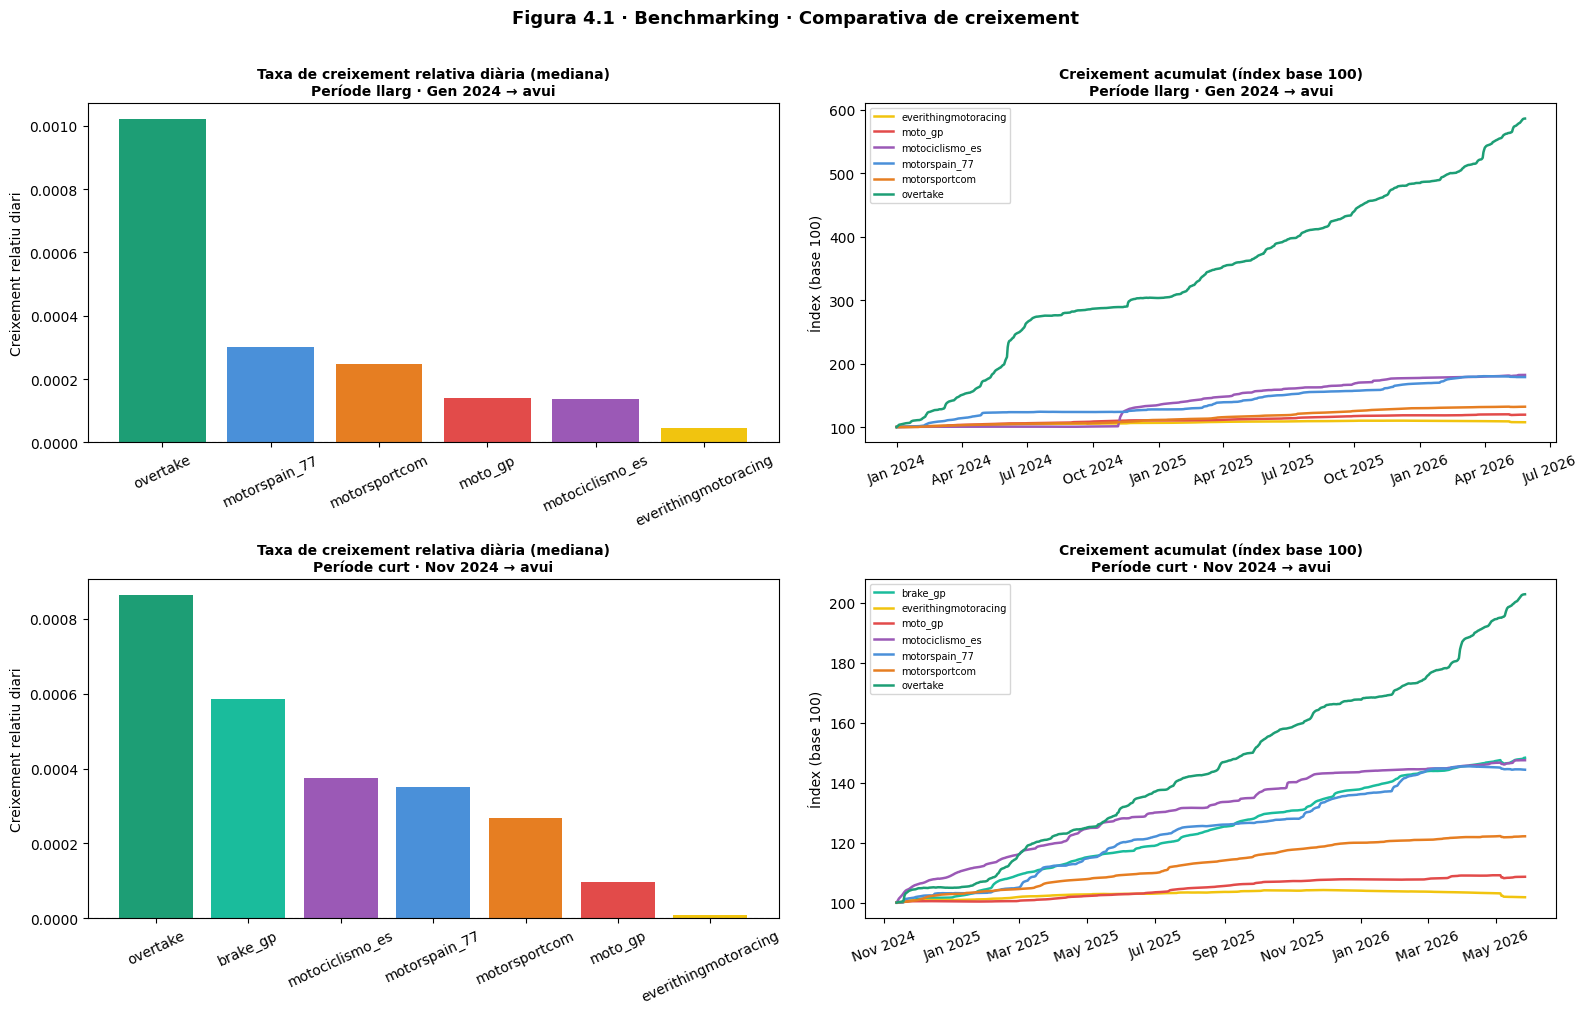

In [141]:
# ── Bloc 4 · Benchmarking · Gràfiques ───────────────────────────────────────
# 4 gràfiques: taxa creixement diari (mediana) i índex base 100
# per període llarg (gen 2024 → avui) i curt (nov 2024 → avui)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# ── Paleta de colors per compte ──────────────────────────────────────────────
colors_comptes = {
    'overtake':             '#1D9E75',
    'motorspain_77':        '#4A90D9',
    'motorsportcom':        '#E67E22',
    'moto_gp':              '#E24B4A',
    'motociclismo_es':      '#9B59B6',
    'everithingmotoracing': '#F1C40F',
    'brake_gp':             '#1ABC9C',
}

# ── 1. Taxa creixement relatiu · Període llarg ───────────────────────────────
ax = axes[0, 0]
resum_llarg = (
    df_llarg.groupby('account')['daily_growth_rel']
    .median()
    .sort_values(ascending=False)
)
colors_bar = [colors_comptes.get(c, '#aaa') for c in resum_llarg.index]
ax.bar(resum_llarg.index, resum_llarg.values, color=colors_bar)
ax.set_title('Taxa de creixement relativa diària (mediana)\nPeríode llarg · Gen 2024 → avui',
             fontsize=10, fontweight='bold')
ax.set_ylabel('Creixement relatiu diari')
ax.tick_params(axis='x', rotation=25)
ax.axhline(0, color='gray', lw=0.8, ls='--')

# ── 2. Índex base 100 · Període llarg ───────────────────────────────────────
ax = axes[0, 1]
for compte, grup in df_llarg.groupby('account'):
    grup = grup.sort_values('date')
    base = grup['followers_count'].iloc[0]
    idx  = (grup['followers_count'] / base * 100)
    ax.plot(grup['date'], idx,
            label=compte,
            color=colors_comptes.get(compte, '#aaa'),
            lw=1.8)
ax.set_title('Creixement acumulat (índex base 100)\nPeríode llarg · Gen 2024 → avui',
             fontsize=10, fontweight='bold')
ax.set_ylabel('Índex (base 100)')
ax.legend(fontsize=7, loc='upper left')
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %Y'))
ax.tick_params(axis='x', rotation=20)

# ── 3. Taxa creixement relatiu · Període curt ───────────────────────────────
ax = axes[1, 0]
resum_curt = (
    df_curt.groupby('account')['daily_growth_rel']
    .median()
    .sort_values(ascending=False)
)
colors_bar = [colors_comptes.get(c, '#aaa') for c in resum_curt.index]
ax.bar(resum_curt.index, resum_curt.values, color=colors_bar)
ax.set_title('Taxa de creixement relativa diària (mediana)\nPeríode curt · Nov 2024 → avui',
             fontsize=10, fontweight='bold')
ax.set_ylabel('Creixement relatiu diari')
ax.tick_params(axis='x', rotation=25)
ax.axhline(0, color='gray', lw=0.8, ls='--')

# ── 4. Índex base 100 · Període curt ────────────────────────────────────────
ax = axes[1, 1]
for compte, grup in df_curt.groupby('account'):
    grup = grup.sort_values('date')
    base = grup['followers_count'].iloc[0]
    idx  = (grup['followers_count'] / base * 100)
    ax.plot(grup['date'], idx,
            label=compte,
            color=colors_comptes.get(compte, '#aaa'),
            lw=1.8)
ax.set_title('Creixement acumulat (índex base 100)\nPeríode curt · Nov 2024 → avui',
             fontsize=10, fontweight='bold')
ax.set_ylabel('Índex (base 100)')
ax.legend(fontsize=7, loc='upper left')
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %Y'))
ax.tick_params(axis='x', rotation=20)

fig.suptitle('Figura 4.1 · Benchmarking · Comparativa de creixement',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig4_1_benchmarking.png', dpi=150, bbox_inches='tight')
plt.show()

## Conclusions · Bloc 4

L'anàlisi comparativa confirma que Overtake.GP lidera la taxa de creixement relatiu diari en els dos períodes analitzats. Partint de 4.603 seguidors el gener de 2024, el compte ha assolit un índex de creixement de 573 (+473%) mentre que el segon compte més dinàmic, Motociclismo.es, només ha assolit un índex de 182 (+82%) en el mateix període.

Aquest resultat és especialment significatiu considerant que Overtake.GP partia com el compte més petit del conjunt analitzat, amb menys d'una cinquena part dels seguidors del segon compte més petit.

### Interpretació comparativa: períodes llarg i curt

Overtake.GP lidera la taxa de creixement relatiu diari en els dos períodes analitzats, confirmant el seu dinamisme de forma consistent.

La reducció de la mediana entre el període llarg (0.10%) i el curt (0.08%) és esperada i s'explica per l'**efecte de saturació relativa**: a mesura que augmenta la base de seguidors, cada nou seguidor representa una fracció menor del total, reduint matemàticament el creixement percentual.

La desviació estàndard d'Overtake segueix sent la més alta del conjunt (0.161 en període curt), consistent amb la major sensibilitat d'un compte de mida reduïda als pics de creixement puntuals i continguts virals.


---
# Bloc 5 · Model predictiu

In [24]:
# Visualitzem la sèrie temporal setmanal
# (setmanal per reduir el soroll diari)
ts = hist.set_index('date')['followers_count'].resample('W').last()

print(f"Observacions setmanals: {len(ts)}")
print(f"Període: {ts.index[0].date()} → {ts.index[-1].date()}")
print(f"\nPrimers valors:\n{ts.head(5)}")
print(f"\nÚltims valors:\n{ts.tail(5)}")

Observacions setmanals: 127
Període: 2023-12-31 → 2026-05-31

Primers valors:
date
2023-12-31    4580
2024-01-07    4795
2024-01-14    4877
2024-01-21    4987
2024-01-28    5090
Freq: W-SUN, Name: followers_count, dtype: int64

Últims valors:
date
2026-05-03    25936
2026-05-10    26231
2026-05-17    26587
2026-05-24    26952
2026-05-31    26996
Freq: W-SUN, Name: followers_count, dtype: int64


In [25]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import numpy as np

# ── Divisió train/test ────────────────────────────────
n_test  = 8
n_train = len(ts) - n_test

train = ts.iloc[:n_train]
test  = ts.iloc[n_train:]

print(f"Train: {len(train)} setmanes · fins {train.index[-1].date()}")
print(f"Test : {len(test)} setmanes  · fins {test.index[-1].date()}")

Train: 119 setmanes · fins 2026-04-05
Test : 8 setmanes  · fins 2026-05-31


In [26]:
# ── Model Holt-Winters ────────────────────────────────
# trend='add'        → tendència additiva (creix de forma constant)
# seasonal=None      → no forcem estacionalitat (la sèrie no és prou llarga
#                       per detectar patrons anuals fiables)
# damped_trend=True  → la tendència s'amorteix amb el temps
#                       (més realista que un creixement infinit)

model = ExponentialSmoothing(
    train,
    trend='add',
    seasonal=None,
    damped_trend=True
)

fit = model.fit(optimized=True)

# Predicció sobre el període de test
pred_test = fit.forecast(n_test)

# ── Avaluació: MAPE ───────────────────────────────────
# MAPE = Mean Absolute Percentage Error
# Mesura l'error mitjà en percentatge → fàcil d'interpretar
mape = np.mean(np.abs((test.values - pred_test.values) / test.values)) * 100

print(f"MAPE: {mape:.2f}%")
print(f"\nComparativa test vs predicció:")
comparativa = pd.DataFrame({
    'Real'    : test.values,
    'Predit'  : pred_test.values.round(0),
    'Error %' : np.abs((test.values - pred_test.values) / test.values * 100).round(2)
}, index=test.index)
print(comparativa)

MAPE: 3.24%

Comparativa test vs predicció:
             Real   Predit  Error %
date                               
2026-04-12  25285  25537.0     1.00
2026-04-19  25481  25996.0     2.02
2026-04-26  25715  26434.0     2.80
2026-05-03  25936  26851.0     3.53
2026-05-10  26231  27248.0     3.88
2026-05-17  26587  27627.0     3.91
2026-05-24  26952  27987.0     3.84
2026-05-31  26996  28331.0     4.95


In [27]:
# ── Projecció 6 mesos endavant ───────────────────────
N_FUTUR = 26  # setmanes

# Reentrenem amb TOTES les dades (train + test)
model_final = ExponentialSmoothing(
    ts,
    trend='add',
    seasonal=None,
    damped_trend=True
)
fit_final = model_final.fit(optimized=True)

# Projecció
projecció = fit_final.forecast(N_FUTUR)

# Interval d'incertesa (± creixent amb el temps)
std_resid = np.std(fit_final.resid)
interval  = [std_resid * np.sqrt(i+1) * 1.96 for i in range(N_FUTUR)]

sup = projecció + interval
inf = projecció - interval

print("=== PROJECCIÓ 6 MESOS ===")
print(f"Avui:          {ts.iloc[-1]:,} seguidors")
print(f"Base (6m):     {projecció.iloc[-1]:,.0f} seguidors")
print(f"Optimista:     {sup.iloc[-1]:,.0f} seguidors")
print(f"Pessimista:    {inf.iloc[-1]:,.0f} seguidors")

=== PROJECCIÓ 6 MESOS ===
Avui:          26,996 seguidors
Base (6m):     29,791 seguidors
Optimista:     31,422 seguidors
Pessimista:    28,159 seguidors


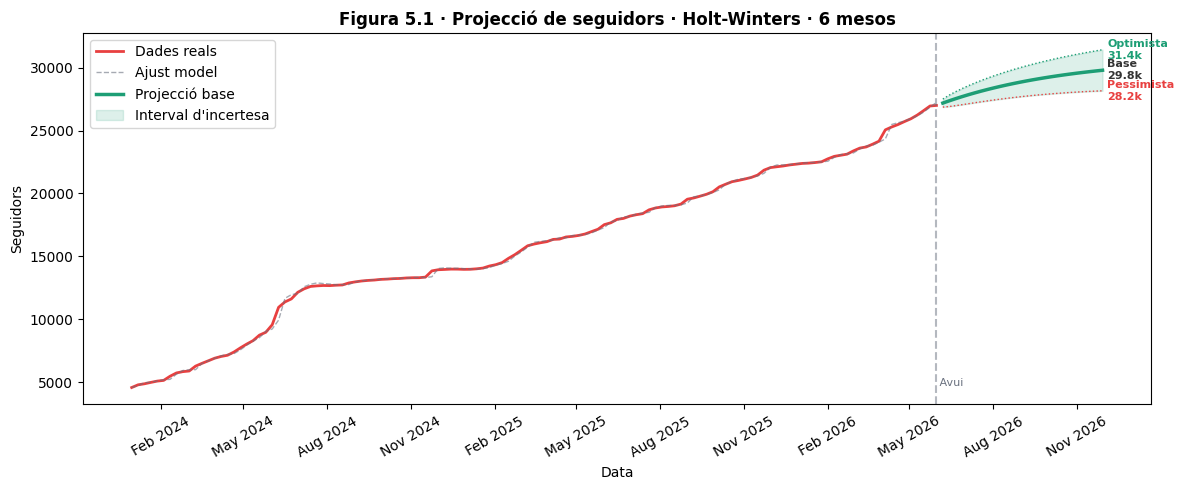

Figura guardada


In [28]:
fig, ax = plt.subplots(figsize=(12, 5))

# Dades històriques
ax.plot(ts.index, ts.values,
        color='#E84040', lw=2, label='Dades reals')

# Ajust del model sobre dades històriques
ax.plot(fit_final.fittedvalues.index, fit_final.fittedvalues.values,
        color='#6B7280', lw=1, ls='--', alpha=0.6, label='Ajust model')

# Projecció base
ax.plot(projecció.index, projecció.values,
        color='#1D9E75', lw=2.5, label='Projecció base')

# Banda d'incertesa
ax.fill_between(projecció.index, inf.values, sup.values,
                alpha=0.15, color='#1D9E75', label='Interval d\'incertesa')

# Línies dels escenaris
ax.plot(projecció.index, sup.values,
        color='#1D9E75', lw=1, ls=':')
ax.plot(projecció.index, inf.values,
        color='#E84040', lw=1, ls=':')

# Línia vertical "avui"
ax.axvline(ts.index[-1], color='#6B7280',
           lw=1.5, ls='--', alpha=0.5)
ax.text(ts.index[-1], ts.values.min() * 1.02,
        ' Avui', fontsize=8, color='#6B7280')

# Anotacions finals
for label, val, color in [
    ('Optimista\n31.4k',  sup.iloc[-1],  '#1D9E75'),
    ('Base\n29.8k',       projecció.iloc[-1], '#333333'),
    ('Pessimista\n28.2k', inf.iloc[-1],  '#E84040'),
]:
    ax.annotate(label,
                 xy=(projecció.index[-1], val),
                xytext=(projecció.index[-1] + pd.Timedelta(days=5), val),
                fontsize=8, color=color, fontweight='bold',
                va='center')

ax.set_title('Figura 5.1 · Projecció de seguidors · Holt-Winters · 6 mesos',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Data')
ax.set_ylabel('Seguidors')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=30)
ax.legend(loc='upper left')
plt.tight_layout()
plt.savefig('fig5_1_projeccio.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura guardada")

In [29]:
# ── MAPE acumulat a 26 setmanes ───────────────────────
# Simulem com hauria predit el model les últimes 26 setmanes
# per estimar l'error a aquest horitzó temporal

n_simulacio = 26

# Entrenem amb les dades excepte les últimes 26 setmanes
train_sim = ts.iloc[:-n_simulacio]
test_sim  = ts.iloc[-n_simulacio:]

model_sim = ExponentialSmoothing(
    train_sim,
    trend='add',
    seasonal=None,
    damped_trend=True
)
fit_sim = model_sim.fit(optimized=True)
pred_sim = fit_sim.forecast(n_simulacio)

# MAPE setmana a setmana
mape_setmanal = np.abs(
    (test_sim.values - pred_sim.values) / test_sim.values * 100
)

# MAPE acumulat
mape_acumulat = pd.DataFrame({
    'Setmana'        : range(1, n_simulacio + 1),
    'Error %'        : mape_setmanal.round(2),
    'MAPE acumulat %': np.cumsum(mape_setmanal) / 
                       np.arange(1, n_simulacio + 1)
}).round(2)

print(mape_acumulat.to_string(index=False))
print(f"\nMAPE final a 26 setmanes: {mape_acumulat['MAPE acumulat %'].iloc[-1]:.2f}%")

 Setmana  Error %  MAPE acumulat %
       1     0.63             0.63
       2     1.23             0.93
       3     1.67             1.18
       4     2.18             1.43
       5     2.62             1.67
       6     3.20             1.92
       7     3.63             2.17
       8     3.96             2.39
       9     3.44             2.51
      10     3.09             2.56
      11     3.19             2.62
      12     3.26             2.67
      13     2.54             2.66
      14     1.98             2.62
      15     1.96             2.57
      16     1.38             2.50
      17     0.71             2.39
      18     2.62             2.40
      19     3.23             2.45
      20     3.71             2.51
      21     4.34             2.60
      22     4.93             2.70
      23     5.79             2.84
      24     6.86             3.01
      25     7.94             3.20
      26     7.92             3.38

MAPE final a 26 setmanes: 3.38%


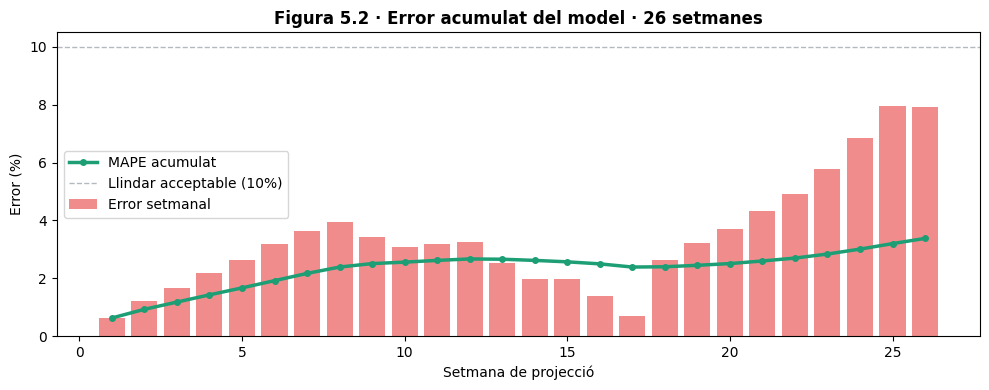

In [30]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.bar(mape_acumulat['Setmana'], mape_acumulat['Error %'],
       color='#E84040', alpha=0.6, label='Error setmanal')
ax.plot(mape_acumulat['Setmana'], mape_acumulat['MAPE acumulat %'],
        color='#1D9E75', lw=2.5, marker='o', ms=4,
        label='MAPE acumulat')
ax.axhline(10, color='#6B7280', lw=1, ls='--',
           alpha=0.5, label='Llindar acceptable (10%)')

ax.set_title('Figura 5.2 · Error acumulat del model · 26 setmanes',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Setmana de projecció')
ax.set_ylabel('Error (%)')
ax.legend()
plt.tight_layout()
plt.savefig('fig5_2_mape_acumulat.png', dpi=150, bbox_inches='tight')
plt.show()

## Model Holt-Winters

Per a la creació d'un model predictiu basat en la sèrie temporal 
d'Overtake.GP hem escollit el model de Holt-Winters (Exponential 
Smoothing). És un model que captura tendència sense necessitat de 
grans volums de dades ni assumpcions complexes, adequat per a 
sèries temporals amb tendència clara i creixement sostingut.

**Validació del model:**
Hem reservat les últimes 8 setmanes com a conjunt de test, 
sense que el model les veiés durant l'entrenament. L'avaluació 
mitjançant MAPE (Mean Absolute Percentage Error) retorna un 
3.24%, per sota del llindar acceptable del 10% en anàlisi de 
xarxes socials. El model és fiable per a projeccions a curt 
i mitjà termini.

L'error creix progressivament (de l'1% a la setmana 1 fins 
al 4.95% a la setmana 8), reflex de la incertesa acumulada 
pròpia de qualsevol model predictiu i de l'alta variabilitat 
intrínseca de la sèrie.

**Projecció a 6 mesos (novembre 2026):**
Reentrenament amb totes les dades disponibles i projecció 
de 26 setmanes:

| Escenari | Seguidors projectats |
|----------|---------------------|
| Optimista | ~31.400 |
| Base | ~29.800 |
| Pessimista | ~28.200 |

Partint dels 26.996 seguidors actuals, la projecció base 
situa el compte proper als **30.000 seguidors** a finals 
de 2026, amb un marge d'incertesa de ±1.600 seguidors. 
L'interval s'eixampla progressivament amb el temps, 
reflectint l'acumulació d'incertesa en projeccions 
a llarg termini.

**Estacionalitat detectada:**
L'anàlisi de l'error setmanal revela un patró consistent amb 
el calendari esportiu del MotoGP: l'error és mínim durant 
l'off-season (gener-març), quan el creixement és més estable, 
i augmenta durant la temporada de competició (abril-juny), 
quan els continguts virals generen pics de creixement 
imprevisibles pel model.

Amb més de 3 temporades completes de dades seria possible 
incorporar estacionalitat anual al model, millorant 
significativament la precisió de les projeccions durant 
els períodes de competició.

## Conclusions · Bloc 5

**Model:** Holt-Winters (Exponential Smoothing) amb tendència 
additiva amortida, entrenat sobre 127 setmanes de dades 
setmanals (des. 2023 → mai 2026).

**Validació:** MAPE del 3.24% sobre les últimes 8 setmanes 
de test, per sota del llindar acceptable del 10% en anàlisi 
de xarxes socials. L'error creix progressivament amb l'horitzó 
temporal, de l'1% a la setmana 1 fins al 4.95% a la setmana 8,
reflex de la incertesa acumulada pròpia de qualsevol model 
predictiu.

**Projecció a 6 mesos (novembre 2026):**

| Escenari | Seguidors projectats |
|----------|---------------------|
| Optimista | ~31.400 |
| Base | ~29.800 |
| Pessimista | ~28.200 |

Partint dels 26.996 seguidors actuals, la projecció base 
situa el compte proper als **30.000 seguidors**, amb un 
marge d'incertesa de ±1.600 seguidors.

**Estacionalitat detectada:** l'anàlisi de l'error setmanal 
revela un patró consistent amb el calendari esportiu del 
MotoGP — l'error és mínim durant l'off-season (gener-març), 
quan el creixement és més estable i predictible, i augmenta 
durant la temporada de competició (abril-juny), quan els 
continguts virals generen pics imprevisibles pel model.

Amb més de 3 temporades completes de dades seria possible 
incorporar estacionalitat anual al model, millorant 
significativament la precisió durant els períodes de 
competició. Aquesta és una línia de millora futura del 
model.

---
# Bloc 6 · Conclusions globals

> 🔲 **Pendent · S'actualitzarà amb les dades finals del 1 de juny de 2026**

Aquest bloc sintetitzarà les conclusions de tots els blocs anteriors un cop disposem del dataset definitiu.


---
# Annex A · API Metricool

## Context

La integració amb l'API de Metricool es va explorar amb dos objectius:
1. Extreure dades demogràfiques de l'audiència (gènere, edat, país, ciutat) no disponibles als CSV exportats
2. Valorar si l'API aportava dades addicionals per a l'anàlisi principal

## Veredicte final

- ✅ Connexió verificada i funcional
- ✅ Dades demogràfiques extretes (instantània estàtica)
- ❌ Instagram no exposa sèries temporals demogràfiques via API
- ❌ Posts i hashtags no accessibles o buits en aquest pla
- **Decisió:** dades demogràfiques com a context descriptiu, sense integrar a l'anàlisi principal

## Nota sobre credencials

El token d'autenticació s'ha eliminat del notebook. Per re-executar aquest annex cal afegir-lo manualment a la variable `API_TOKEN` i no pujar mai el token a Git.

## Dades extretes i desades

Les dades demogràfiques s'han desat als fitxers:
- `metricool_demografia.json` — estructura completa
- `overtake_demographics_gender.csv` · `_age.csv` · `_country.csv` · `_city.csv`


In [ ]:
 
# ── Annex · API Metricool · Test de connexió ────────────────────────────────

API_TOKEN = os.environ.get("METRICOOL_TOKEN", "")  # afegir via variable d'entorn
USER_ID   = "1043183"
BLOG_ID   = "5945902"

BASE_URL  = "https://app.metricool.com/api"

HEADERS = {
    "X-Mc-Auth": API_TOKEN,
    "Content-Type": "application/json"
}

demographics = {
    "gender":   [],  # [{"key": "M", "value": 72.8}, ...]
    "age":      [],
    "country": [],
    "city": [],
    "postsTypes" : []
}
demo = ["gender", "age","country", "city", "postsTypes"]

for i in demo:
    resp = requests.get(
        f"{BASE_URL}/v2/analytics/distribution?from=2025-05-28T00:00:00&to=2026-05-28T23:59:59",
        headers=HEADERS,
        params={"userId": USER_ID, "blogId" : "5945902", "network" : "instagram", "subject" : "account", "metric": i }
    )
    print(i, resp.status_code, resp.json())
    demographics[i] = resp.json()["data"]

print(f"Status: {resp.status_code}")
try:
    print(resp.json())
except Exception:
    print(resp.text[:500])


In [95]:
# ── Verificació abans de desar ───────────────────────────────────────────────
for key, value in demographics.items():
    print(f"{key}: {len(value)} registres → {value[:2]}")

gender: 3 registres → [{'key': 'U', 'value': 20.74}, {'key': 'F', 'value': 6.46}]
age: 8 registres → [{'key': '25-34', 'value': 37.37}, {'key': '18-24', 'value': 20.86}]
country: 45 registres → [{'key': 'DE', 'value': 2.8}, {'key': 'RS', 'value': 0.79}]
city: 45 registres → [{'key': 'Samarinda, East Kalimantan', 'value': 0.25}, {'key': 'Banyumas, Central Java', 'value': 0.22}]
postsTypes: 0 registres → []


In [96]:
with open('metricool_demografia.json', 'w', encoding='utf-8') as f:
    json.dump(demographics, f, ensure_ascii=False, indent=2)

# Verificació que el fitxer té contingut
import os
mida = os.path.getsize('metricool_demografia.json')
print(f"Fitxer desat · {mida} bytes")

Fitxer desat · 6646 bytes


In [97]:
with open('metricool_demografia.json', 'r', encoding='utf-8') as f:
    demo = json.load(f)

for key, value in demo.items():
    print(f"{key}: {len(value)} registres")

gender: 3 registres
age: 8 registres
country: 45 registres
city: 45 registres
postsTypes: 0 registres


In [98]:
import pandas as pd

for metric, data in demographics.items():
    df = pd.DataFrame(data)
    df["metric"] = metric
    df.to_csv(f"overtake_demographics_{metric}.csv", index=False)
    mida = os.path.getsize(f"overtake_demographics_{metric}.csv")
    print(f"overtake_demographics_{metric}.csv · {mida} bytes · {len(df)} registres")

overtake_demographics_gender.csv · 64 bytes · 3 registres
overtake_demographics_age.csv · 143 bytes · 8 registres
overtake_demographics_country.csv · 781 bytes · 45 registres
overtake_demographics_city.csv · 1611 bytes · 45 registres
overtake_demographics_postsTypes.csv · 8 bytes · 0 registres


Conclusions de l'Annex · API Metricool

La integració amb l'API ha permès obtenir una instantània demogràfica de l'audiència d'Overtake.GP no disponible al CSV:

Gènere: ~73% masculí, ~6.5% femení, ~21% no especificat
País i ciutat: disponibles com a distribució agregada

Aquesta dada reforça el context del TFG: Overtake.GP opera en un nínxol (motorsport) amb audiència majoritàriament masculina, cosa coherent amb el perfil històric del sector. Pot usar-se per contextualitzar les decisions de contingut — formats, temes, to comunicatiu.
Limitació crítica identificada: Instagram no exposa dades demogràfiques històriques via API. La resposta és invariable independentment del rang de dates sol·licitat, confirmant que es tracta d'una foto estàtica de l'audiència actual, no d'una sèrie temporal. Això impedeix qualsevol creuament amb l'evolució de seguidors o el rendiment de posts.
Valoració final: l'API no aporta dades noves per a l'anàlisi principal. El valor és infraestructural i descriptiu — documenta el perfil d'audiència i valida la connexió tècnica, però no genera variables explicatives addicionals per als blocs 0-5 del notebook.

Pel que fa a la resta de dades a extreure a través de la API, son les mateixes que obtenim descarregant els CSV directament del UI de la app.

---
# Annex B · MySQL · Procés explorat i descartat

## Context

Durant el desenvolupament inicial del projecte es va explorar l'ús d'una base de dades MySQL local per emmagatzemar els datasets i facilitar consultes complexes.

## Motiu del descart

Amb un volum de dades de ~11.000 files i 7 comptes, la complexitat d'una base de dades relacional no aportava valor respecte a treballar directament amb DataFrames de pandas en memòria. El temps de configuració i manteniment superava els beneficis per a aquest volum de dades.

## Codi preservat (desactivat)

El codi es conserva com a referència per a futures extensions del projecte amb volums de dades majors.

## Nota sobre credencials

Les credencials MySQL (usuari `root`, contrasenya `root`, host local) s'han eliminat de les constants del Bloc 0. No contenien informació sensible al tractar-se d'un servidor local de desenvolupament, però s'eliminen per bones pràctiques.


In [ ]:
'''
# ── Connexió MySQL ───────────────────────────────────────
# TODO: substituir per variables d'entorn (.env) abans de pujar a Git
engine = create_engine(
    f'mysql+pymysql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}/{DB_NAME}',
    pool_size=5, pool_recycle=3600, echo=False
)

# Exportem tots els DataFrames a MySQL
for nom, df in [
    ('comptes',      df_comptes),
    ('comptes_llarg', df_llarg),
    ('comptes_curt',  df_curt),
]:
    df.to_sql(nom, con=engine, if_exists='replace', index=False)
    print(f'  MySQL · taula "{nom}" actualitzada ({len(df):,} files)')

'''